# Modelo supervisado de clasificación para detección de URLs de phishing
---
Autor: Pablo García Santos

## Pregunta del problema
> **¿Podemos distinguir si una URL pertenece a una página legítima o a una página de phishing a partir de sus características?**

## Estructura del notebook
1. carga del dataset;
2. preparación de los datos;
3. análisis exploratorio;
4. modelado;
5. evaluación;
6. interpretación de resultados;
7. análisis de errores.

En este notebook utilizaremos el dataset **PhiUSIIL Phishing URL (Website)** del repositorio oficial de UCI.

## 0 - Instalación de dependencias necesarias

In [1]:
# ---------------------------------------------------------------------
# Instalación de dependencias necesarias para ejecutar este notebook
# ---------------------------------------------------------------------

%pip install -q ucimlrepo xgboost pandas numpy matplotlib seaborn scikit-learn jinja2 ipython

Note: you may need to restart the kernel to use updated packages.


## 0.1 - Importación de librerías y configuración del entorno

In [2]:
# ---------------------------------------------------------------------
# Importación de librerías
# ---------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from ucimlrepo import fetch_ucirepo

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from xgboost import XGBClassifier

# ---------------------------------------------------------------------
# Configuración visual
# ---------------------------------------------------------------------
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# 1 - Carga, comprensión y preparación inicial del dataset

## 1.1 - Carga del dataset desde UCI

In [3]:
# ---------------------------------------------------------------------
# Descarga del dataset desde el repositorio oficial de UCI
# ---------------------------------------------------------------------
dataset = fetch_ucirepo(id=967)

# Separación original entre variables predictoras y variable objetivo
X_original = dataset.data.features.copy()
y_original = dataset.data.targets.copy()

# Metadatos y diccionario de variables
metadata = dataset.metadata
variables = dataset.variables

print("Dataset cargado correctamente.")
print("Número de filas en X:", X_original.shape[0])
print("Número de columnas en X:", X_original.shape[1])
print("Nombre(s) de la variable objetivo:", y_original.columns.tolist())

Dataset cargado correctamente.
Número de filas en X: 235795
Número de columnas en X: 54
Nombre(s) de la variable objetivo: ['label']


In [4]:
# Vista rápida de las variables del dataset
display(variables.head(15))

,name,role,type,demographic,description,units,missing_values
0,FILENAME,Other,Categorical,None,None,None,no
1,URL,Feature,Categorical,None,None,None,no
2,URLLength,Feature,Integer,None,None,None,no
3,Domain,Feature,Categorical,None,None,None,no
4,DomainLength,Feature,Integer,None,None,None,no
5,IsDomainIP,Feature,Integer,None,None,None,no
6,TLD,Feature,Categorical,None,None,None,no
7,URLSimilarityIndex,Feature,Integer,None,None,None,no
8,CharContinuationRate,Feature,Integer,None,None,None,no
9,TLDLegitimateProb,Feature,Continuous,None,None,None,no


## 1.2 - Construcción del dataframe de trabajo

In [ ]:
# ---------------------------------------------------------------------
# Unión de características y target en un único dataframe
# ---------------------------------------------------------------------
columna_objetivo_original = y_original.columns[0]

datos_brutos = pd.concat([X_original, y_original], axis=1).copy()

# Renombramos la variable objetivo original para mayor claridad.
datos_brutos = datos_brutos.rename(columns={columna_objetivo_original: "target_original"})

# ---------------------------------------------------------------------
# Reinterpretación del target
# ---------------------------------------------------------------------
# En la documentación oficial del dataset:
# - 1 = URL legítima
# - 0 = URL phishing
#
# Más natural definir:
# - 1 = phishing
# - 0 = legítima
#
# Así, métricas como recall o sensitivity se interpretan como la
# capacidad del modelo para detectar phishing.
datos_brutos["target"] = 1 - datos_brutos["target_original"]

print("Shape del dataframe bruto:", datos_brutos.shape)
display(datos_brutos.head())

Shape del dataframe bruto: (235795, 56)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,target_original,target
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1,0
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1,0
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1,0
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1,0
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1,0


In [6]:
# ---------------------------------------------------------------------
# Comprobación de la nueva codificación del target
# ---------------------------------------------------------------------
tabla_target = (
    datos_brutos["target"]
    .value_counts(dropna=False)
    .rename_axis("target")
    .reset_index(name="frecuencia")
)

tabla_target["clase"] = tabla_target["target"].map({0: "Legítima", 1: "Phishing"})
tabla_target["porcentaje"] = 100 * tabla_target["frecuencia"] / tabla_target["frecuencia"].sum()

display(tabla_target[["target", "clase", "frecuencia", "porcentaje"]])

,target,clase,frecuencia,porcentaje
0,0,Legítima,134850,57.189508
1,1,Phishing,100945,42.810492


## 1.3 - Preparación metodológica del dataset

El dataset original contiene variables muy útiles para el análisis, pero no todas son igual de convenientes para un primer modelo tabular clásico.

Tomaremos estas decisiones:

- **FILENAME** se eliminará porque la propia documentación indica que puede ignorarse.
- **URL** y **Domain** se conservarán para el análisis de errores, pero **no se usarán como variables de entrada** en este baseline tabular, ya que son identificadores/texto de alta cardinalidad.
- **TLD** se excluirá del primer modelo para mantener una base numérica limpia y fácilmente interpretable.
- El modelado principal se realizará con **variables numéricas**.

In [7]:
# ---------------------------------------------------------------------
# Copia del dataset para modelado
# ---------------------------------------------------------------------
datos_modelo = datos_brutos.copy()

columnas_a_excluir_modelado = [
    columna for columna in ["FILENAME", "URL", "Domain", "TLD", "target_original"]
    if columna in datos_modelo.columns
]

datos_modelo = datos_modelo.drop(columns=columnas_a_excluir_modelado).copy()

# Selección explícita de columnas numéricas + target
columnas_numericas = datos_modelo.select_dtypes(include=[np.number]).columns.tolist()

if "target" not in columnas_numericas:
    raise ValueError("La variable objetivo 'target' no se encuentra en las columnas numéricas.")

columnas_caracteristicas = [col for col in columnas_numericas if col != "target"]

datos_modelo = datos_modelo[columnas_caracteristicas + ["target"]].copy()

print("Shape del dataset para modelado:", datos_modelo.shape)
print("Número de variables numéricas utilizadas:", len(columnas_caracteristicas))
display(datos_modelo.head())

Shape del dataset para modelado: (235795, 51)
Número de variables numéricas utilizadas: 50


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,target
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,0
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,0
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,0
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,0
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,0


# 2 - Exploración y análisis exploratorio de los datos (EDA)

## 2.1 - Inspección inicial del dataset

In [8]:
# Información general
print("Primeras dimensiones del dataset:", datos_modelo.shape)
print("")
display(datos_modelo.head())
print("")
datos_modelo.info()

Primeras dimensiones del dataset: (235795, 51)



,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,target
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,0
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,0
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,0
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,0
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,0



<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 51 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URLLength                   235795 non-null  int64  
 1   DomainLength                235795 non-null  int64  
 2   IsDomainIP                  235795 non-null  int64  
 3   URLSimilarityIndex          235795 non-null  float64
 4   CharContinuationRate        235795 non-null  float64
 5   TLDLegitimateProb           235795 non-null  float64
 6   URLCharProb                 235795 non-null  float64
 7   TLDLength                   235795 non-null  int64  
 8   NoOfSubDomain               235795 non-null  int64  
 9   HasObfuscation              235795 non-null  int64  
 10  NoOfObfuscatedChar          235795 non-null  int64  
 11  ObfuscationRatio            235795 non-null  float64
 12  NoOfLettersInURL            235795 non-null  int64  
 13  LetterRatioInURL        

In [9]:
# ---------------------------------------------------------------------
# Valores ausentes
# ---------------------------------------------------------------------
tabla_nulos = (
    datos_modelo.isna()
    .sum()
    .rename("nulos")
    .reset_index()
    .rename(columns={"index": "columna"})
)

tabla_nulos["porcentaje_nulos"] = 100 * tabla_nulos["nulos"] / len(datos_modelo)
tabla_nulos = tabla_nulos.sort_values(by="nulos", ascending=False)

display(tabla_nulos.head(20))

,columna,nulos,porcentaje_nulos
0,URLLength,0,0.0
1,DomainLength,0,0.0
2,IsDomainIP,0,0.0
3,URLSimilarityIndex,0,0.0
4,CharContinuationRate,0,0.0
5,TLDLegitimateProb,0,0.0
6,URLCharProb,0,0.0
7,TLDLength,0,0.0
8,NoOfSubDomain,0,0.0
9,HasObfuscation,0,0.0


### Interpretación inicial

Antes de entrenar un modelo, conviene responder a varias preguntas:

- ¿el dataset está equilibrado o desbalanceado?
- ¿hay muchas variables?
- ¿hay valores nulos?
- ¿hay variables claramente relacionadas con el objetivo?

Estas comprobaciones ayudan a tomar mejores decisiones durante el modelado.

## 2.2 - Distribución de la variable objetivo

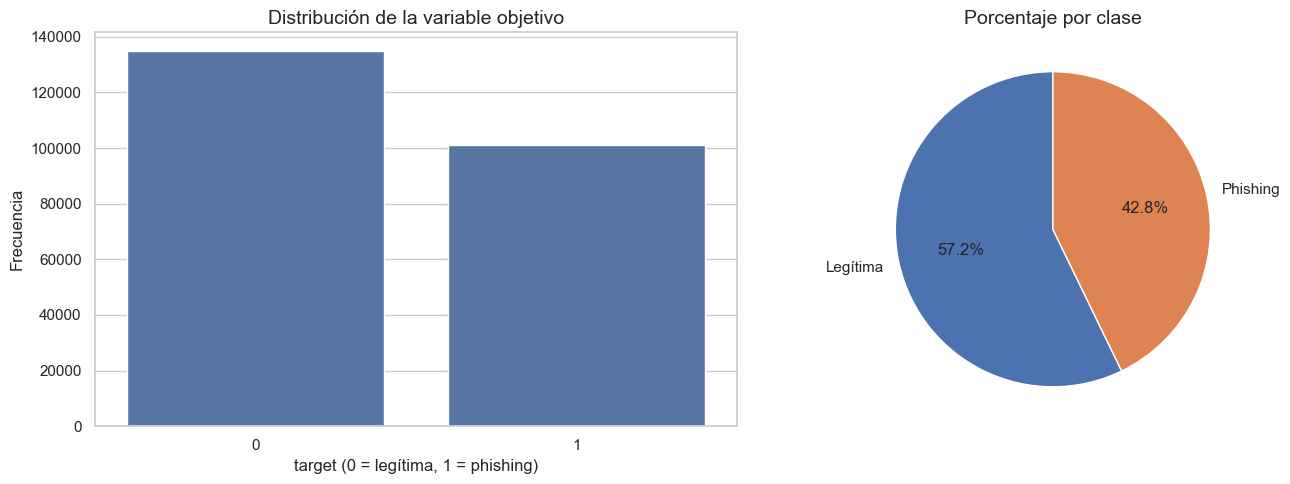

In [10]:
# ---------------------------------------------------------------------
# Distribución de la variable objetivo
# ---------------------------------------------------------------------
conteo_target = datos_modelo["target"].value_counts().sort_index()
porcentaje_target = 100 * conteo_target / conteo_target.sum()

figura, ejes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=datos_modelo, x="target", ax=ejes[0])
ejes[0].set_title("Distribución de la variable objetivo")
ejes[0].set_xlabel("target (0 = legítima, 1 = phishing)")
ejes[0].set_ylabel("Frecuencia")

ejes[1].pie(
    porcentaje_target.values,
    labels=["Legítima", "Phishing"],
    autopct="%1.1f%%",
    startangle=90
)
ejes[1].set_title("Porcentaje por clase")

plt.tight_layout()
plt.show()

## 2.3 - Estadística descriptiva de las variables numéricas

In [11]:
resumen_numerico = datos_modelo[columnas_caracteristicas].describe().T
display(resumen_numerico)

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


## 2.4 - Relación entre variables y objetivo

Una forma muy útil de empezar a interpretar el dataset es calcular la correlación lineal de cada variable con el target.

**Importante:** la correlación no implica causalidad, pero sí puede darnos una primera pista sobre qué variables parecen más informativas.

In [12]:
# ---------------------------------------------------------------------
# Correlación con la variable objetivo
# ---------------------------------------------------------------------
correlacion_target = (
    datos_modelo.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda serie: serie.abs(), ascending=False)
)

tabla_correlacion = correlacion_target.reset_index()
tabla_correlacion.columns = ["variable", "correlacion_con_target"]

display(tabla_correlacion.head(20))

,variable,correlacion_con_target
0,URLSimilarityIndex,-0.860358
1,HasSocialNet,-0.784255
2,HasCopyrightInfo,-0.743358
3,HasDescription,-0.690232
4,IsHTTPS,-0.609132
5,DomainTitleMatchScore,-0.584905
6,HasSubmitButton,-0.578561
7,IsResponsive,-0.548608
8,URLTitleMatchScore,-0.539419
9,SpacialCharRatioInURL,0.533537


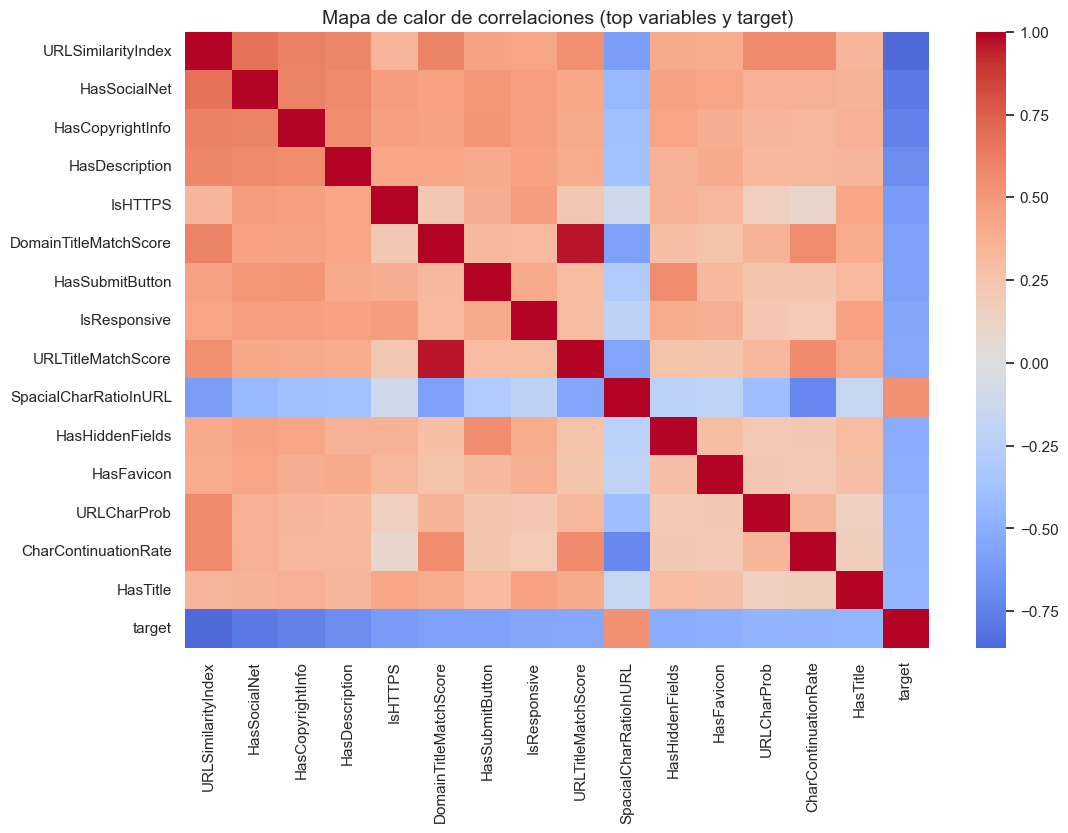

In [13]:
# ---------------------------------------------------------------------
# Heatmap con las variables más relacionadas con el target
# ---------------------------------------------------------------------
variables_top_corr = correlacion_target.abs().sort_values(ascending=False).head(15).index.tolist()
variables_heatmap = variables_top_corr + ["target"]

matriz_corr = datos_modelo[variables_heatmap].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, cmap="coolwarm", center=0, annot=False)
plt.title("Mapa de calor de correlaciones (top variables y target)")
plt.show()

## 2.5 - Función de visualización para variables numéricas

In [14]:
def graficar_variable_numerica(datos_entrada, nombre_columna, variable_objetivo="target"):
    '''
    Muestra una variable numérica desde dos perspectivas:

    1. distribución general;
    2. distribución condicionada por la variable objetivo.

    Esto permite estudiar si la variable tiene capacidad de separación
    entre URLs legítimas y URLs de phishing.
    '''

    if nombre_columna not in datos_entrada.columns:
        raise ValueError(f"La columna '{nombre_columna}' no existe en el DataFrame.")

    if variable_objetivo not in datos_entrada.columns:
        raise ValueError(f"La variable objetivo '{variable_objetivo}' no existe en el DataFrame.")

    datos_grafico = datos_entrada[[nombre_columna, variable_objetivo]].dropna().copy()

    figura, ejes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(data=datos_grafico, x=nombre_columna, hue=variable_objetivo, bins=30, kde=True, ax=ejes[0], element="step")
    ejes[0].set_title(f"Distribución de {nombre_columna}")
    ejes[0].set_xlabel(nombre_columna)
    ejes[0].set_ylabel("Frecuencia")
    ejes[0].legend(["Legítima", "Phishing"])

    sns.boxplot(data=datos_grafico, x=variable_objetivo, y=nombre_columna, ax=ejes[1])
    ejes[1].set_title(f"{nombre_columna} según la clase")
    ejes[1].set_xlabel("target (0 = legítima, 1 = phishing)")
    ejes[1].set_ylabel(nombre_columna)

    plt.tight_layout()
    plt.show()

## 2.6 - Análisis detallado de las variables más informativas

In [15]:
# ---------------------------------------------------------------------
# Selección automática de variables destacadas para el EDA
# ---------------------------------------------------------------------
# Para no saturar el notebook con decenas de gráficos, tomamos las
# variables con mayor correlación absoluta con el target.
columnas_numericas_eda = correlacion_target.abs().sort_values(ascending=False).head(8).index.tolist()

print("Variables seleccionadas para el análisis detallado:")
print(columnas_numericas_eda)

Variables seleccionadas para el análisis detallado:
['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton', 'IsResponsive']



--- Análisis de la variable numérica: URLSimilarityIndex ---


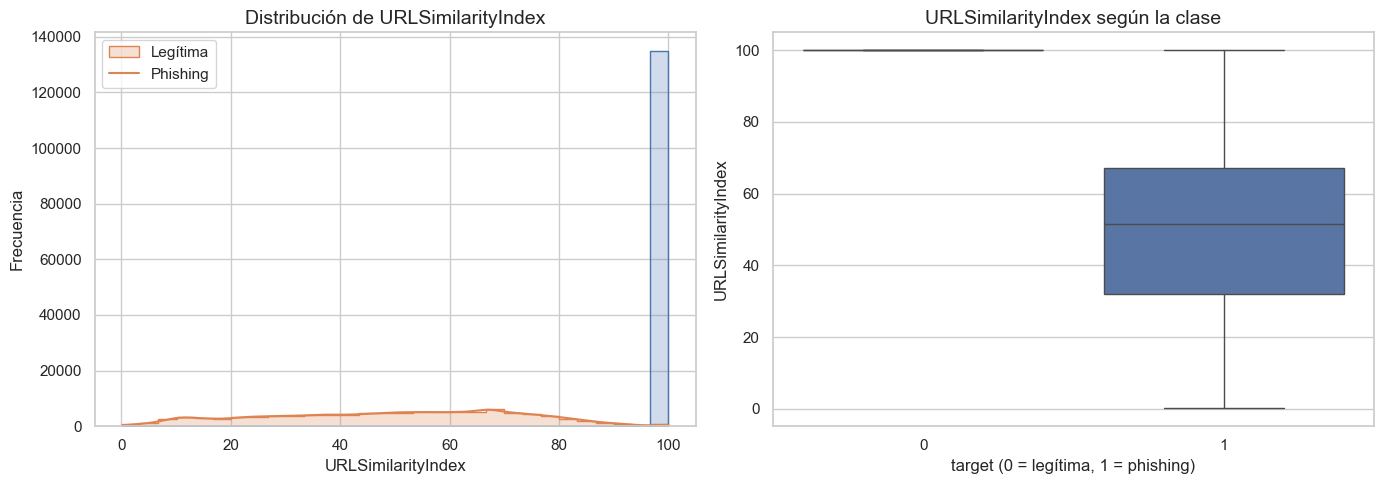


--- Análisis de la variable numérica: HasSocialNet ---


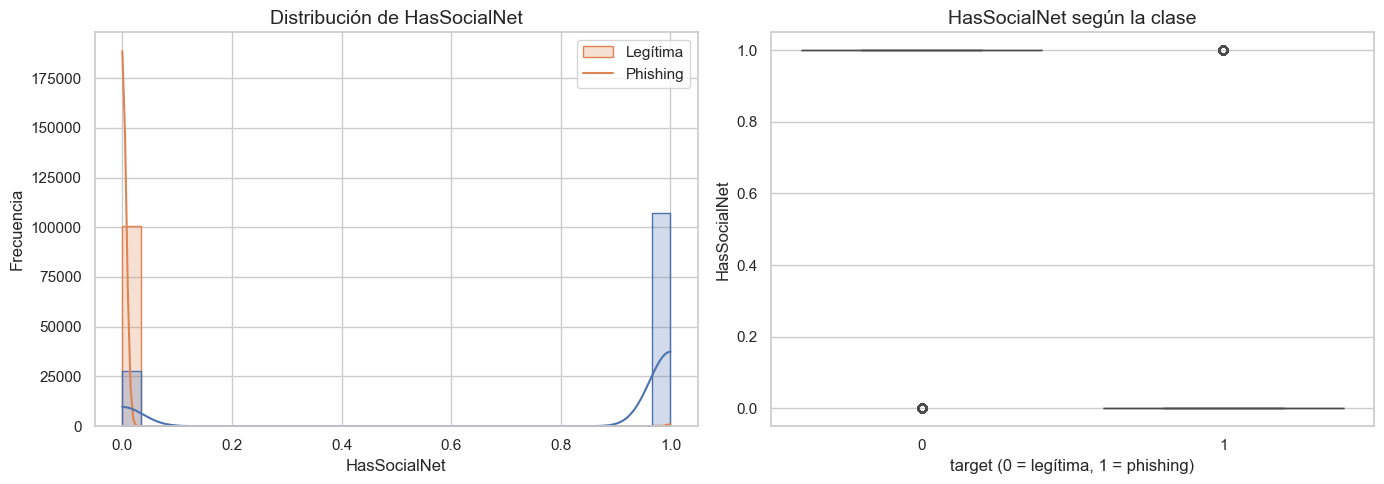


--- Análisis de la variable numérica: HasCopyrightInfo ---


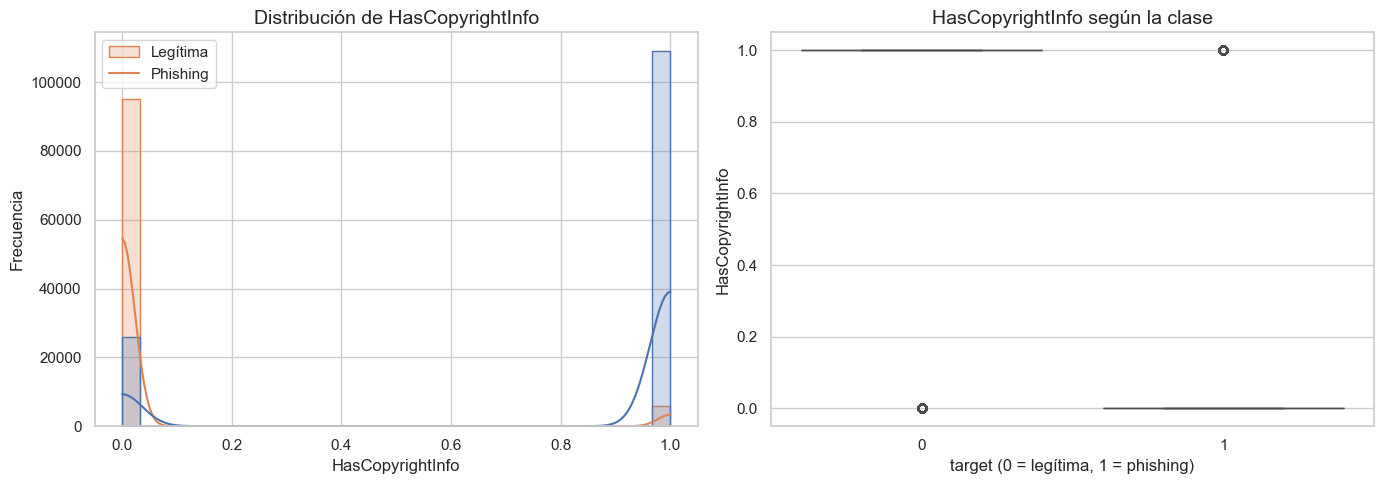


--- Análisis de la variable numérica: HasDescription ---


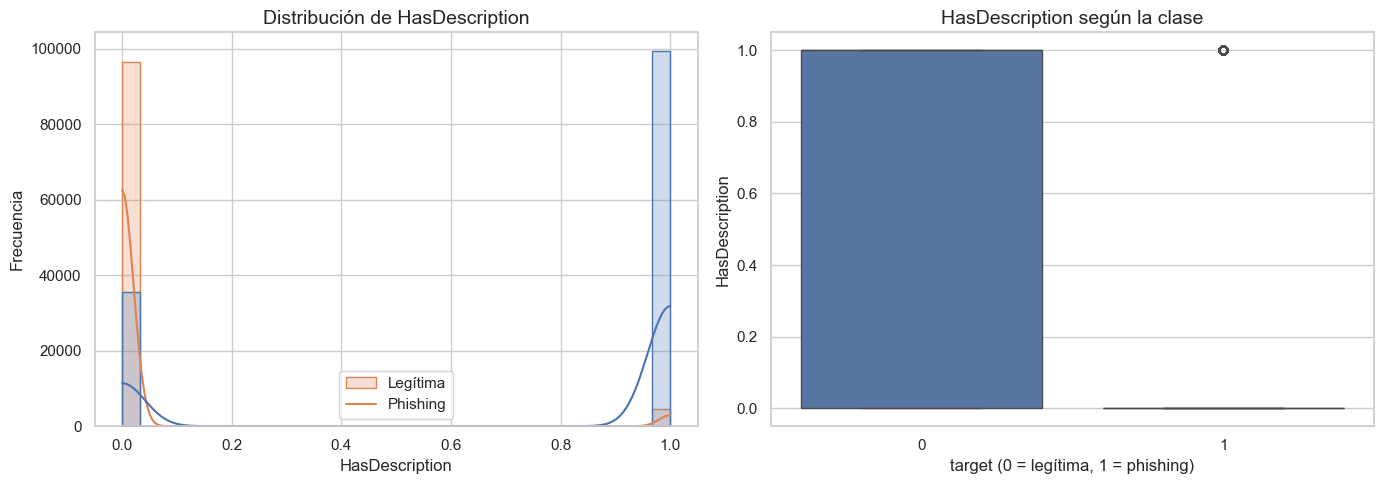


--- Análisis de la variable numérica: IsHTTPS ---


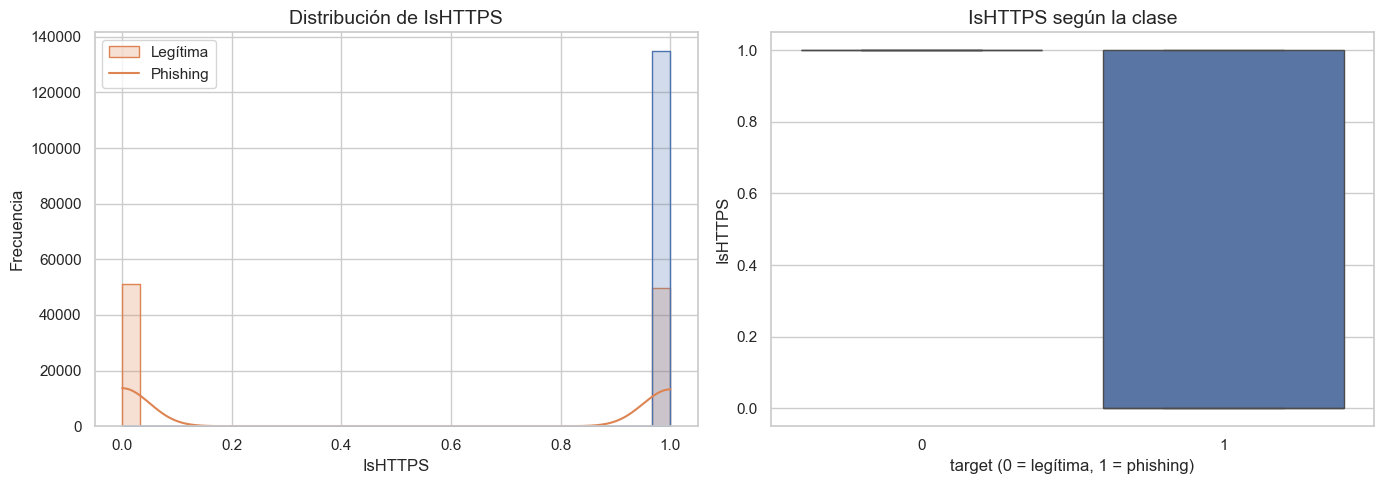


--- Análisis de la variable numérica: DomainTitleMatchScore ---


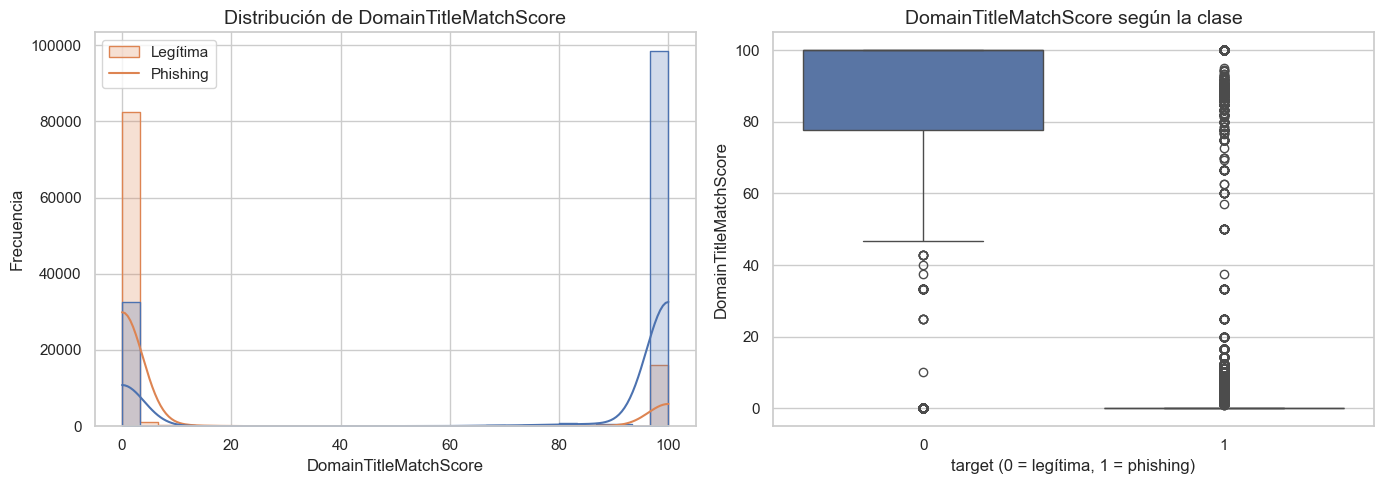


--- Análisis de la variable numérica: HasSubmitButton ---


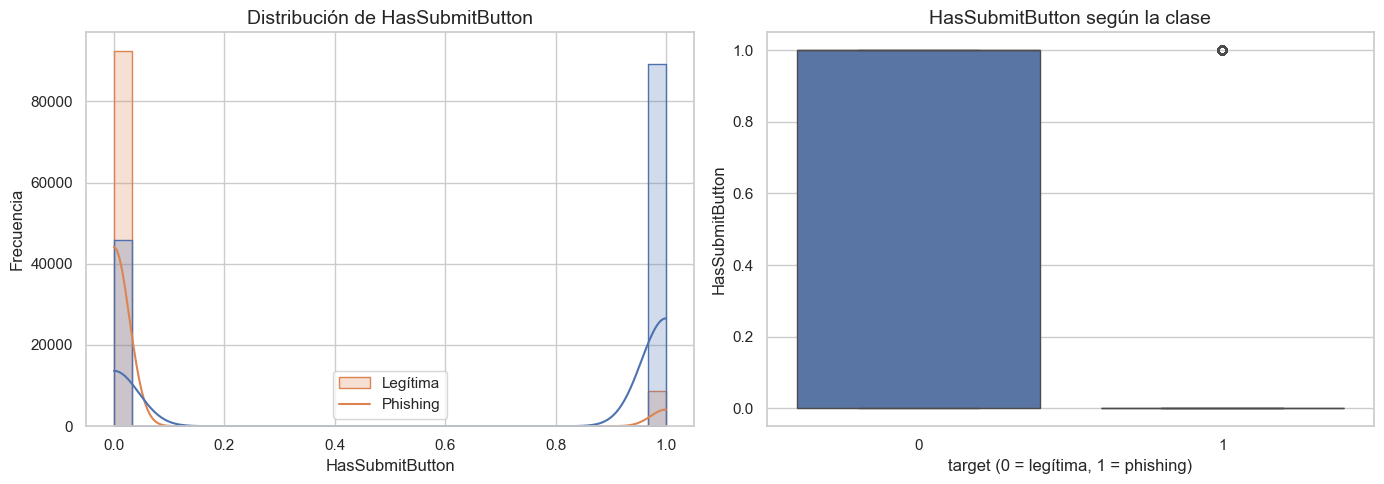


--- Análisis de la variable numérica: IsResponsive ---


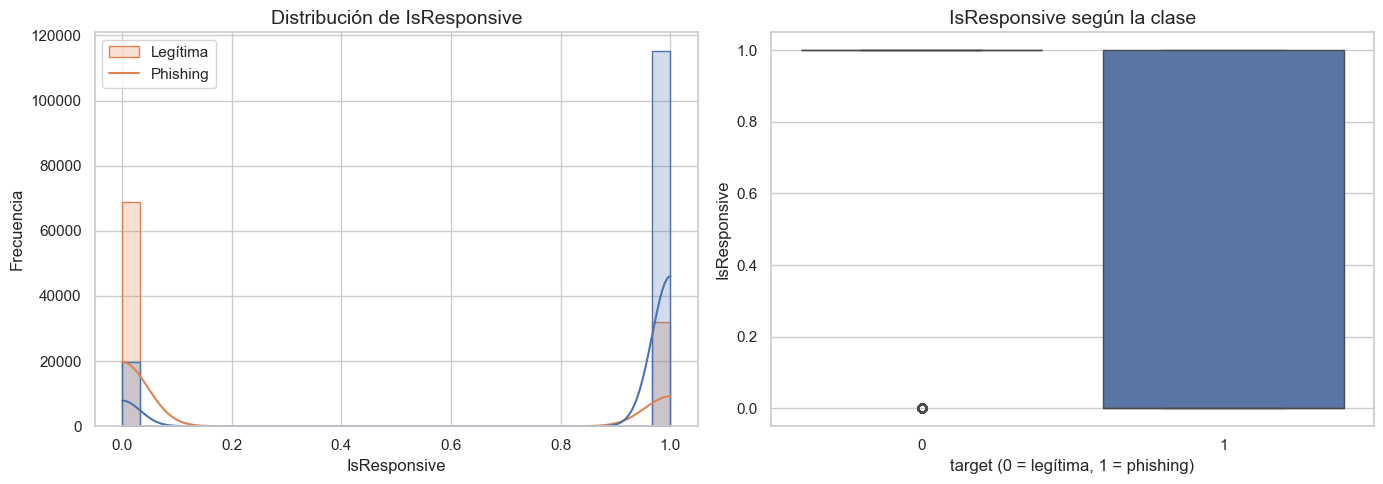

In [16]:
for columna in columnas_numericas_eda:
    print(f"\n--- Análisis de la variable numérica: {columna} ---")
    graficar_variable_numerica(datos_modelo, columna)

## 2.7 - Análisis opcional de todas las variables numéricas

La siguiente celda puede activarse si se quiere un análisis exhaustivo variable por variable.

Podemos desactivar para no tener una salida excesivamente larga


--- Análisis completo de: URLLength ---


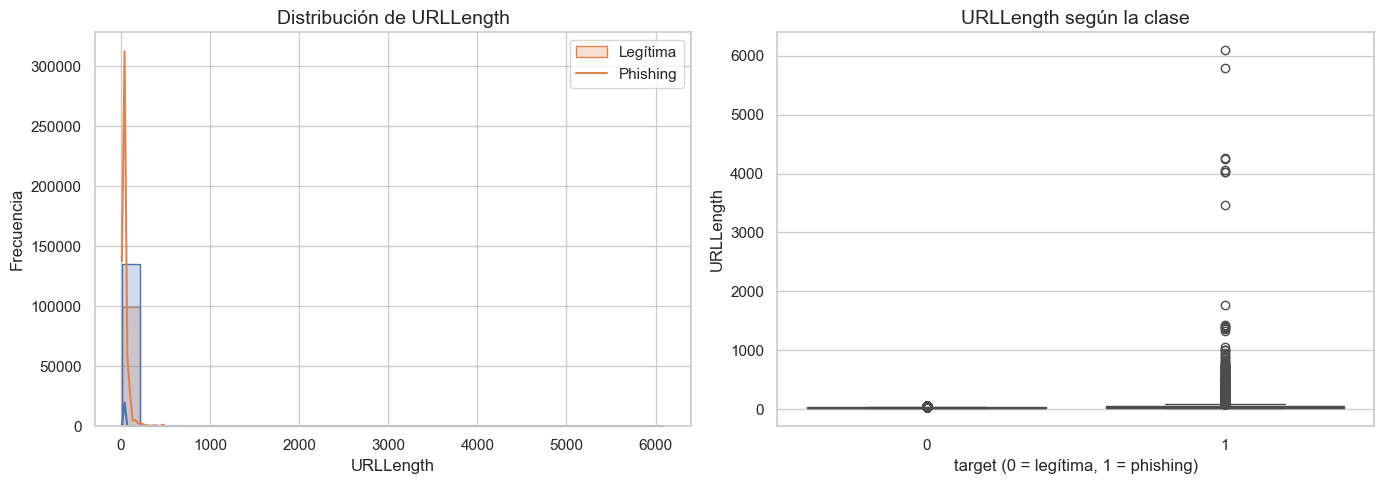


--- Análisis completo de: DomainLength ---


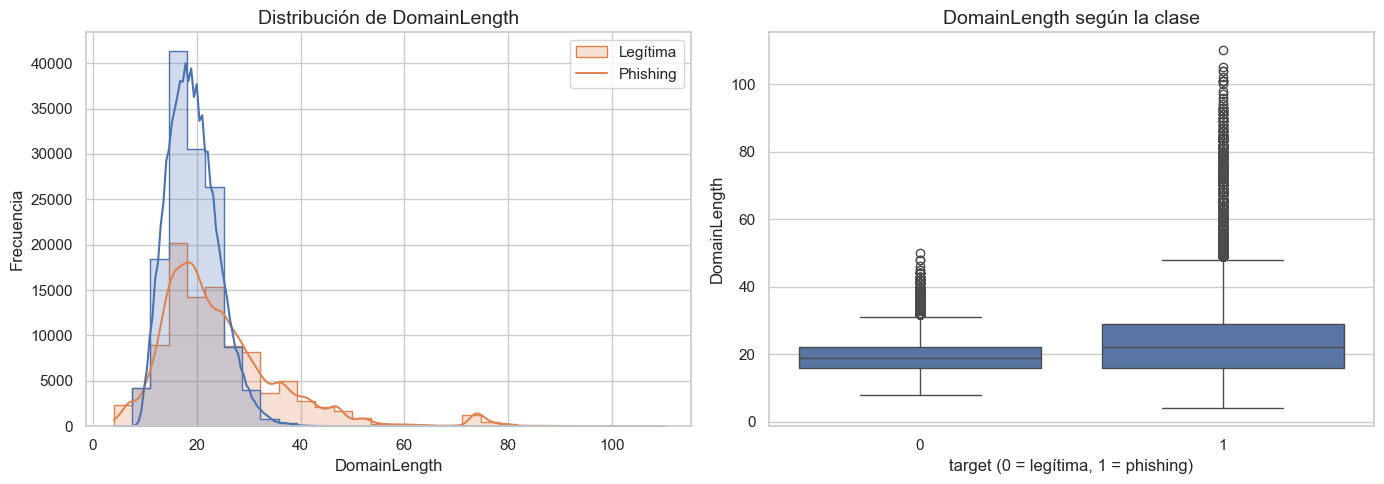


--- Análisis completo de: IsDomainIP ---


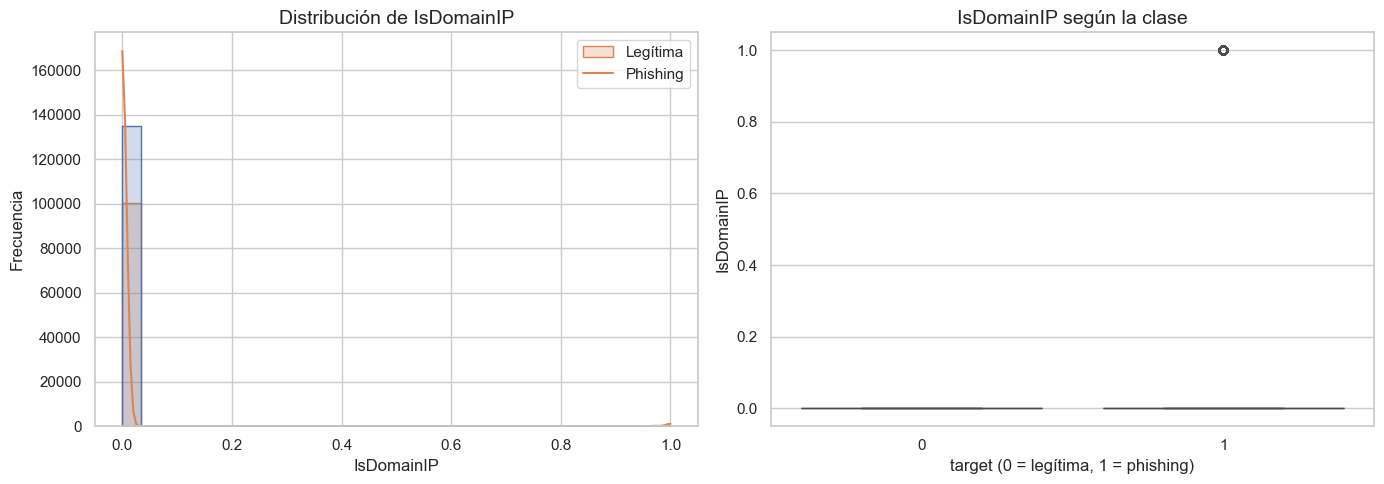


--- Análisis completo de: URLSimilarityIndex ---


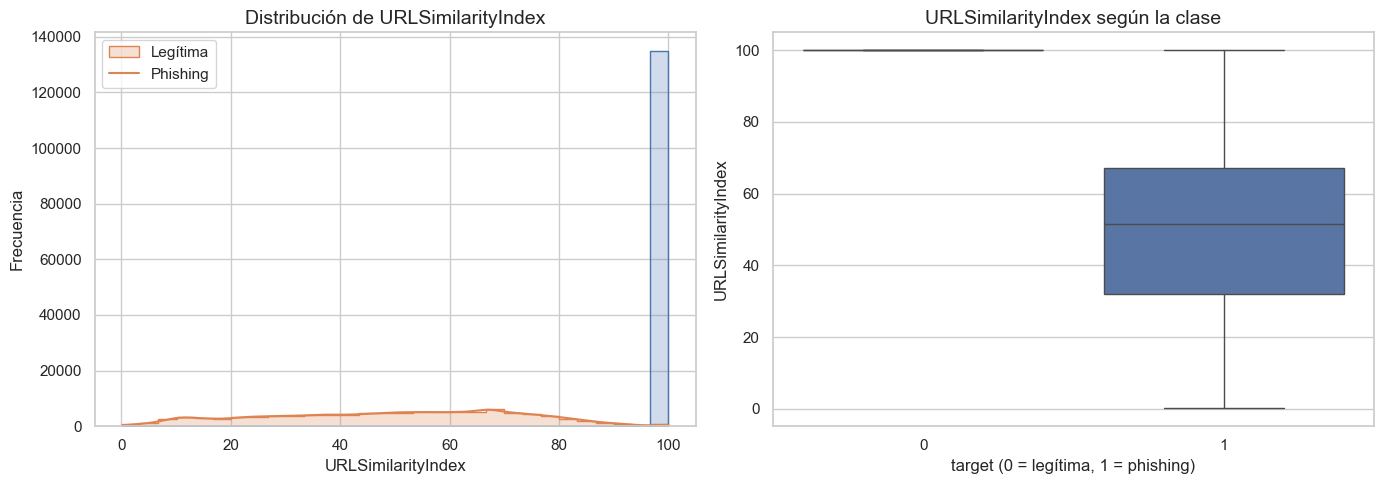


--- Análisis completo de: CharContinuationRate ---


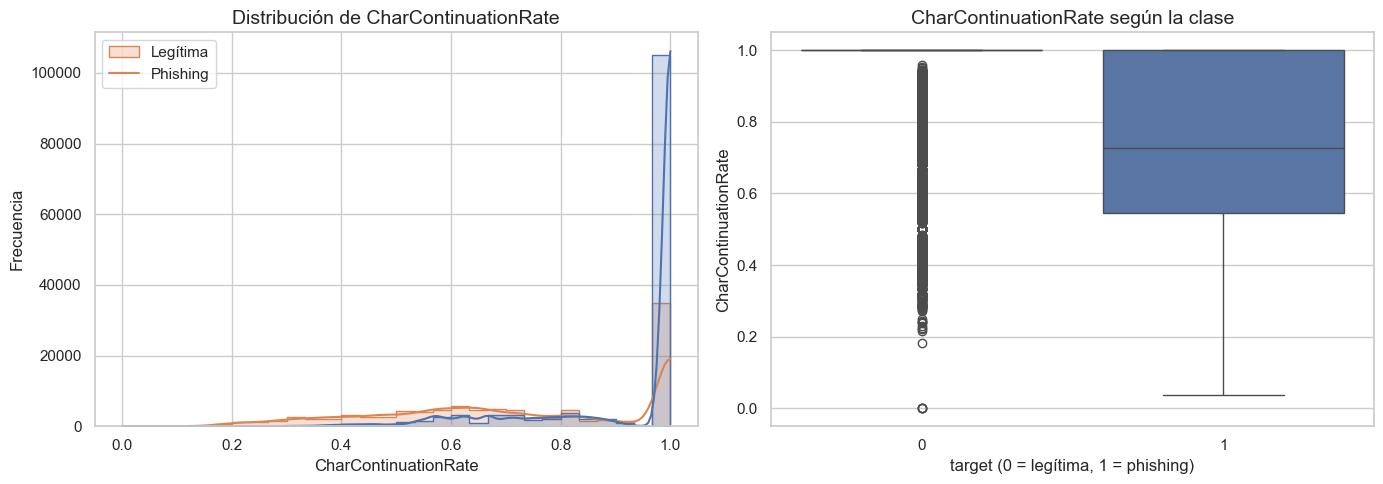


--- Análisis completo de: TLDLegitimateProb ---


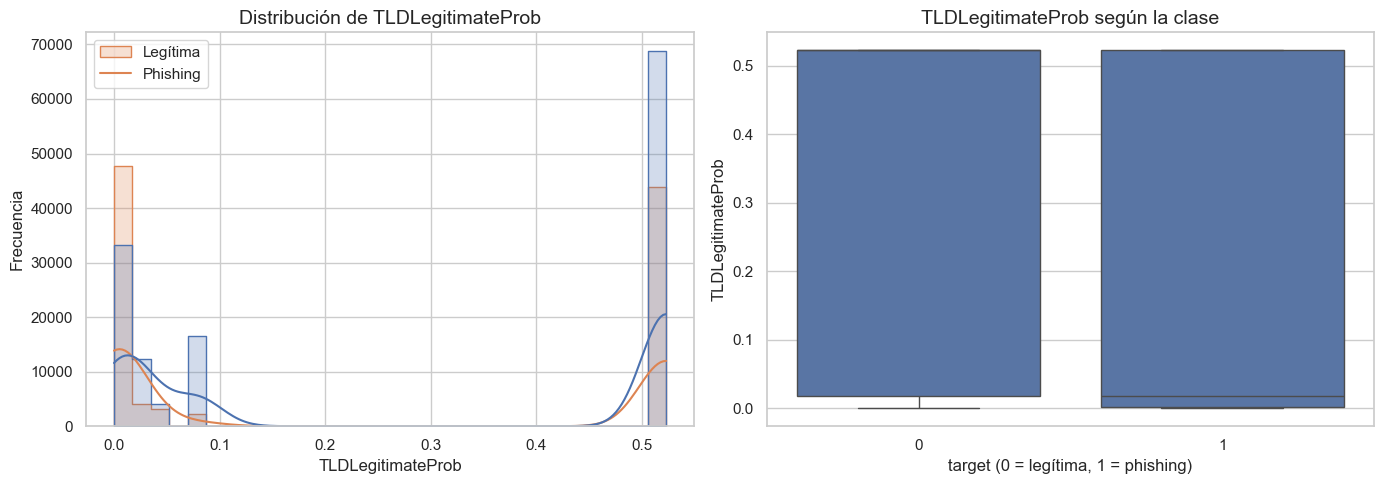


--- Análisis completo de: URLCharProb ---


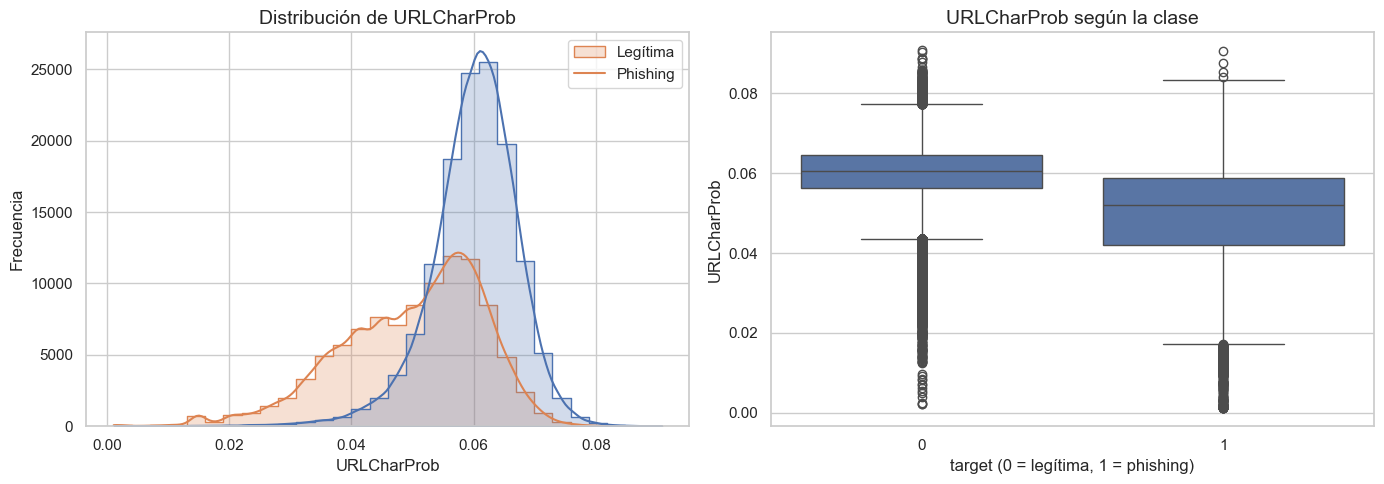


--- Análisis completo de: TLDLength ---


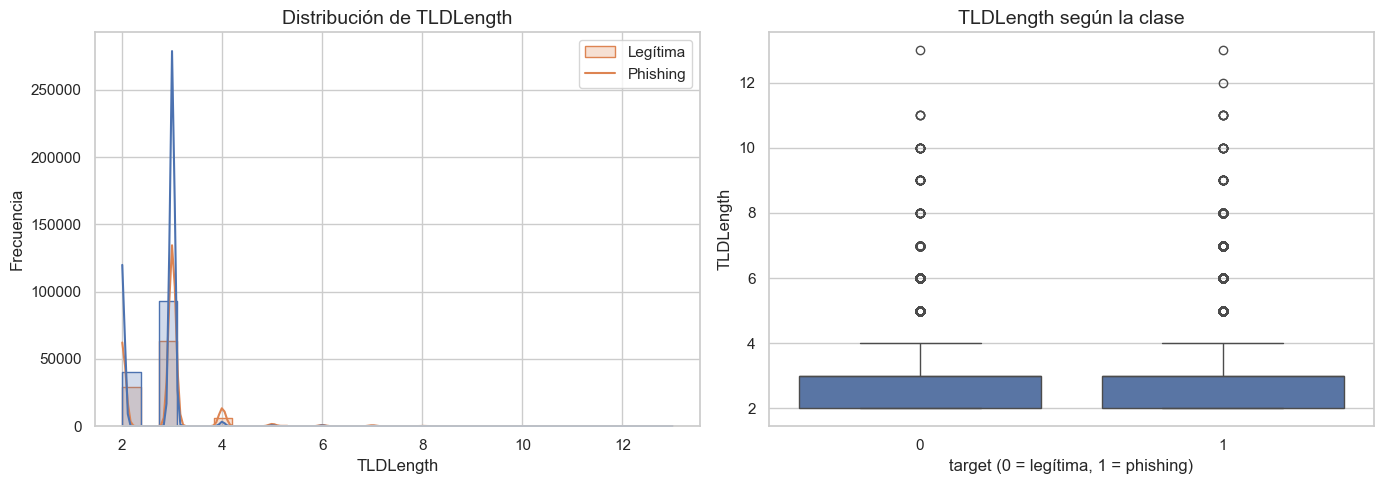


--- Análisis completo de: NoOfSubDomain ---


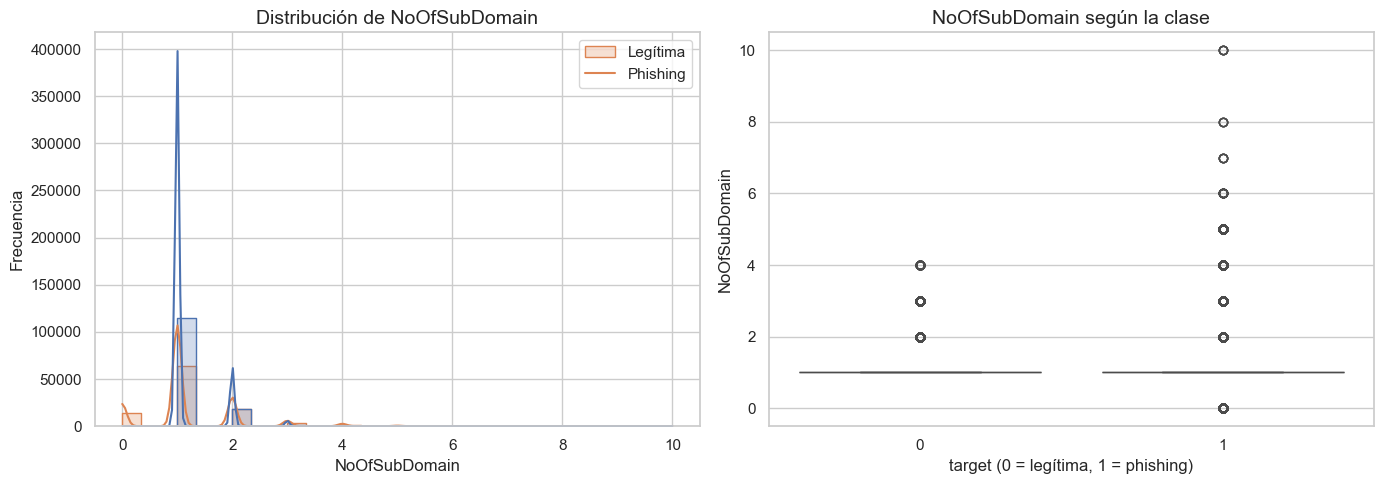


--- Análisis completo de: HasObfuscation ---


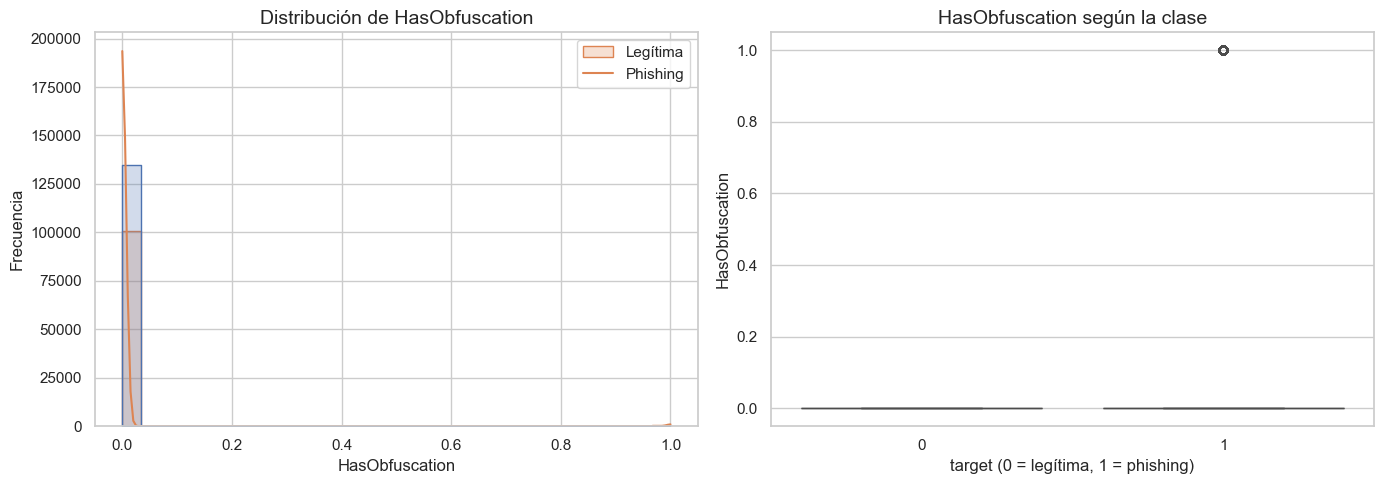


--- Análisis completo de: NoOfObfuscatedChar ---


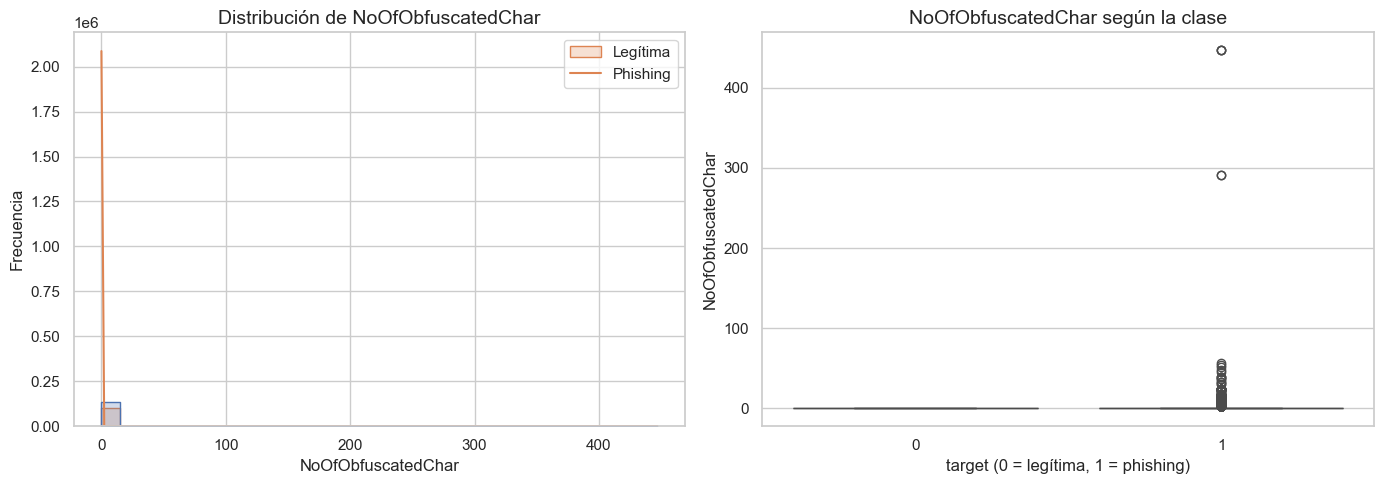


--- Análisis completo de: ObfuscationRatio ---


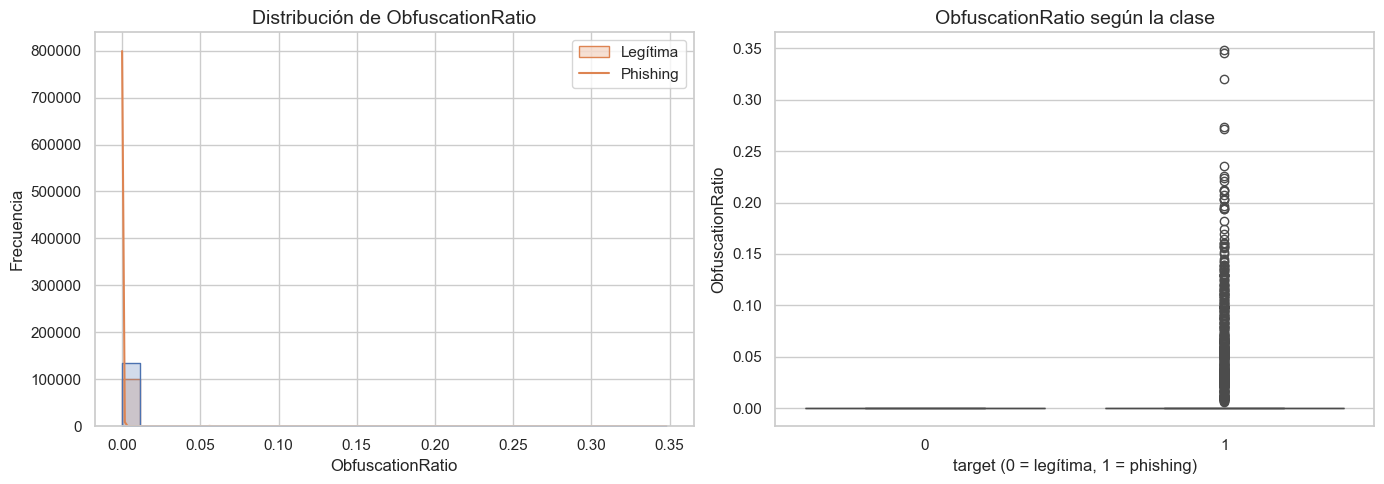


--- Análisis completo de: NoOfLettersInURL ---


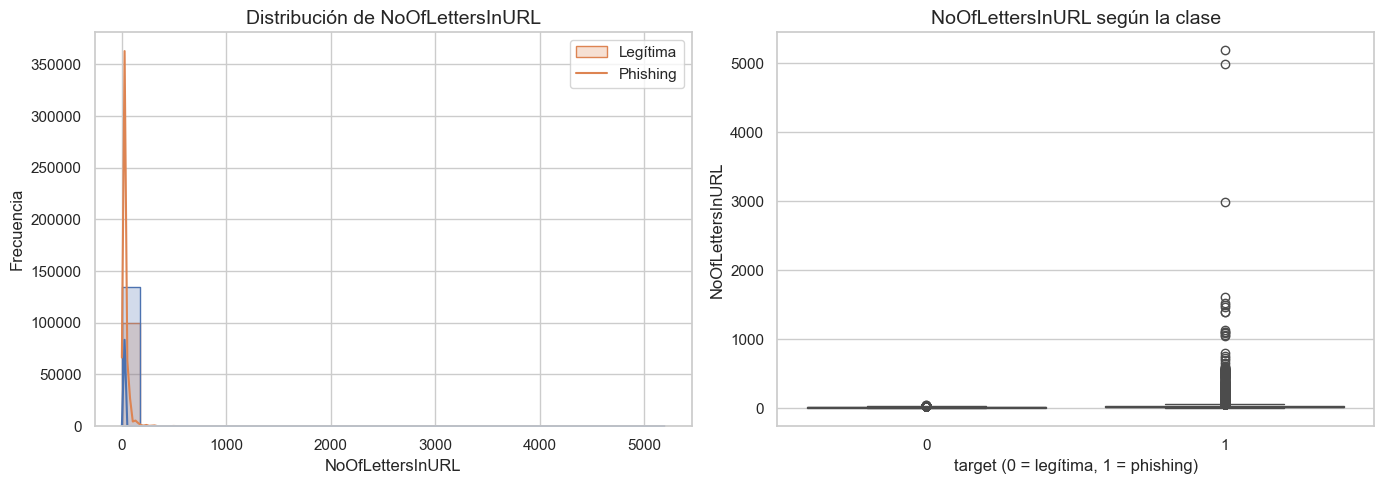


--- Análisis completo de: LetterRatioInURL ---


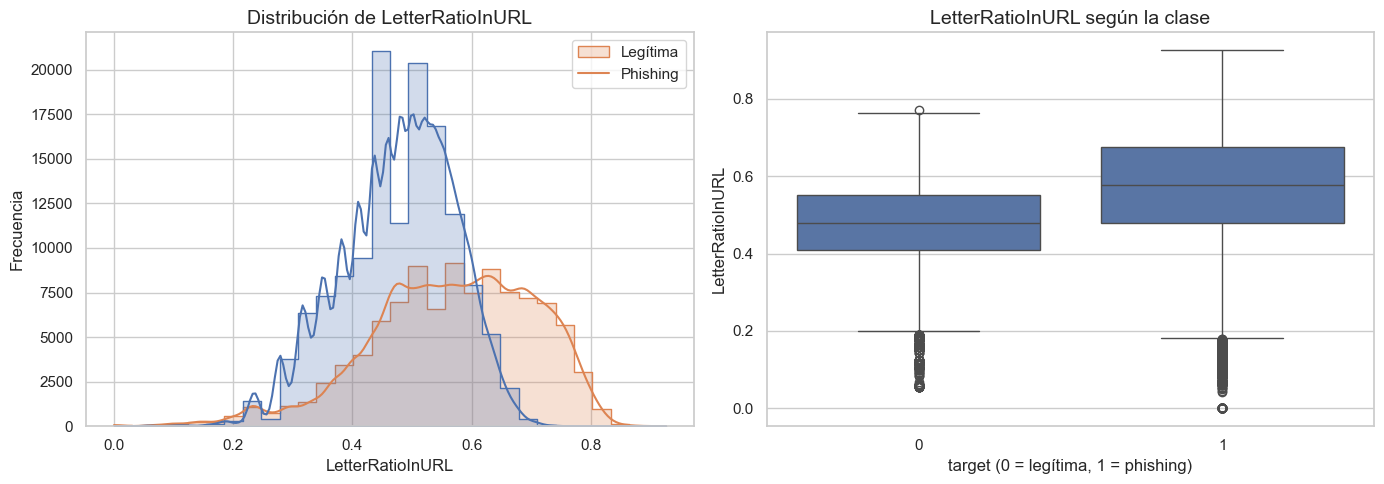


--- Análisis completo de: NoOfDegitsInURL ---


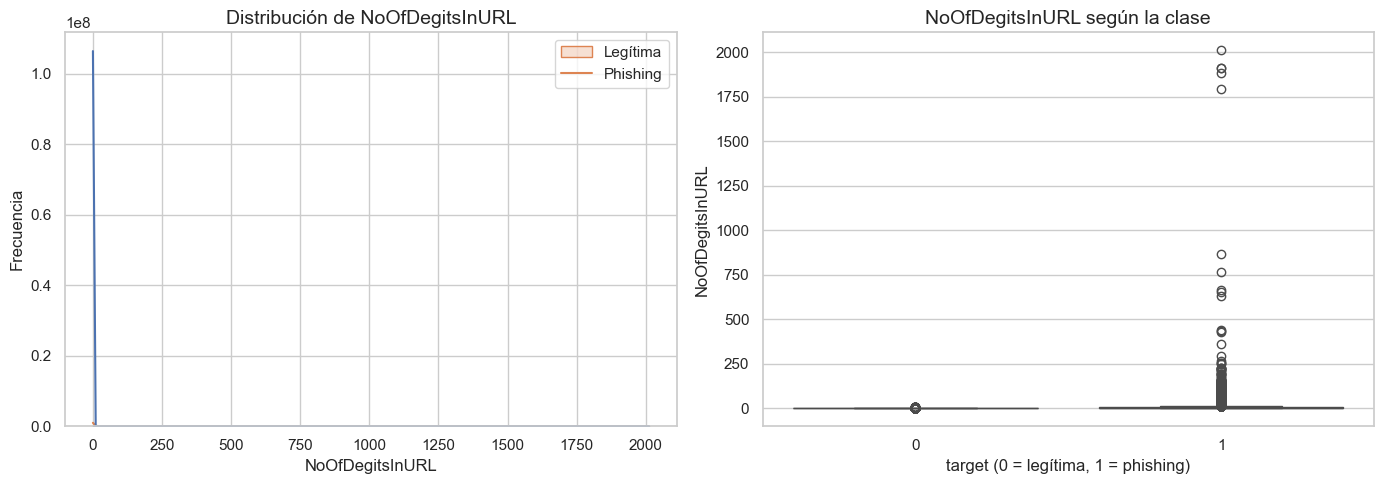


--- Análisis completo de: DegitRatioInURL ---


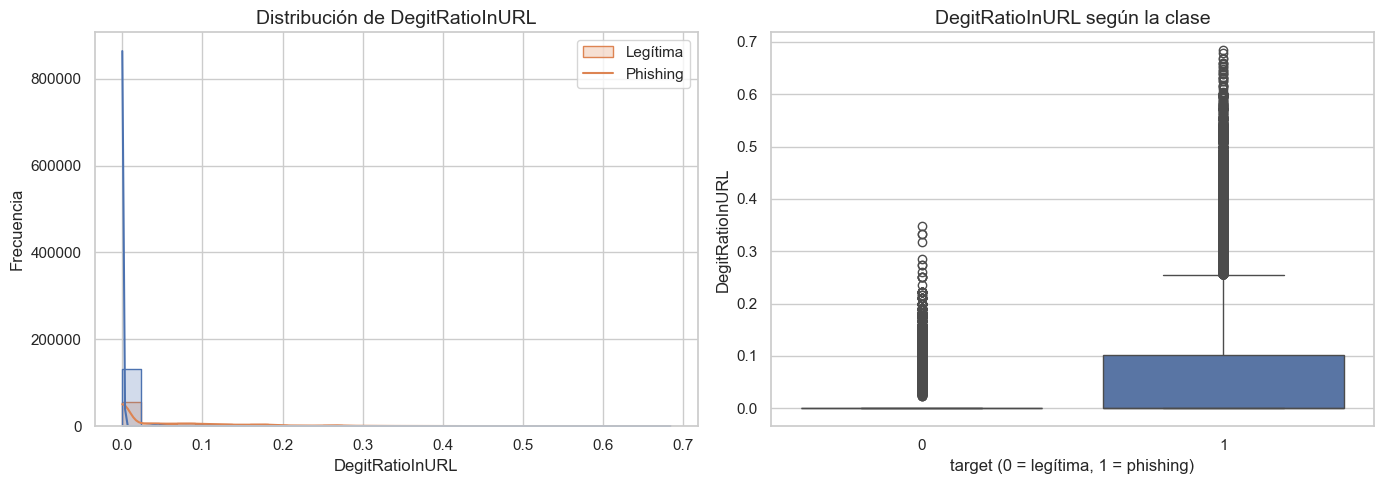


--- Análisis completo de: NoOfEqualsInURL ---


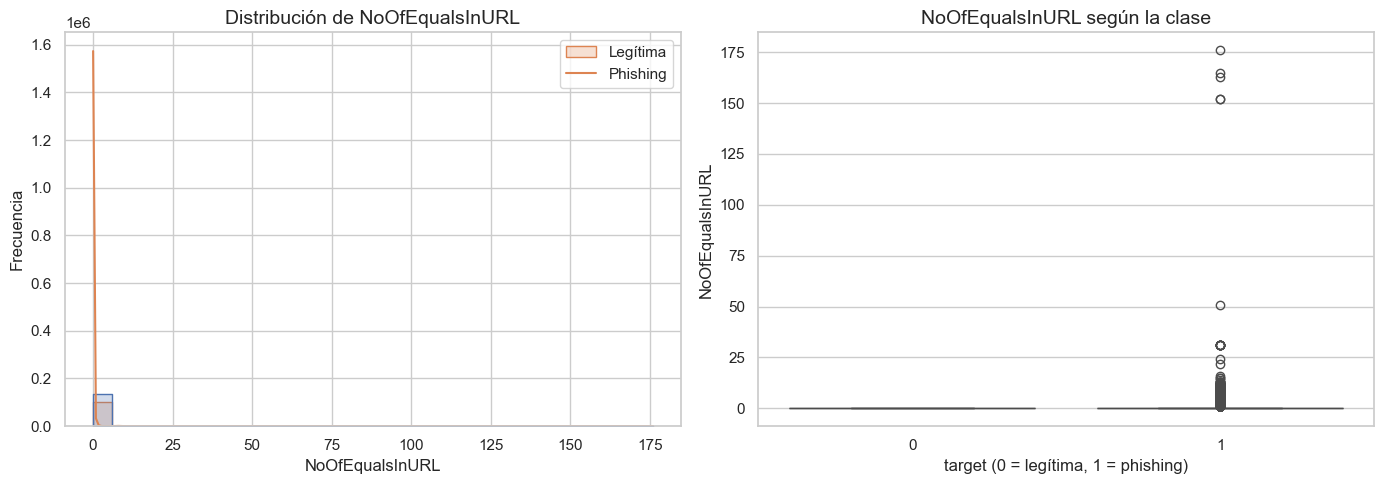


--- Análisis completo de: NoOfQMarkInURL ---


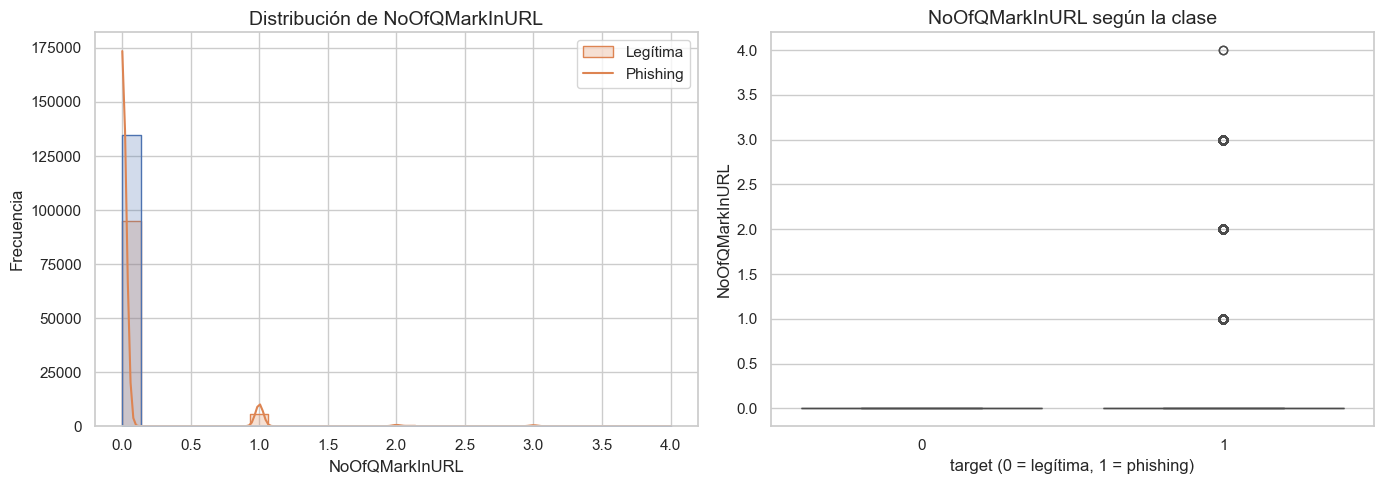


--- Análisis completo de: NoOfAmpersandInURL ---


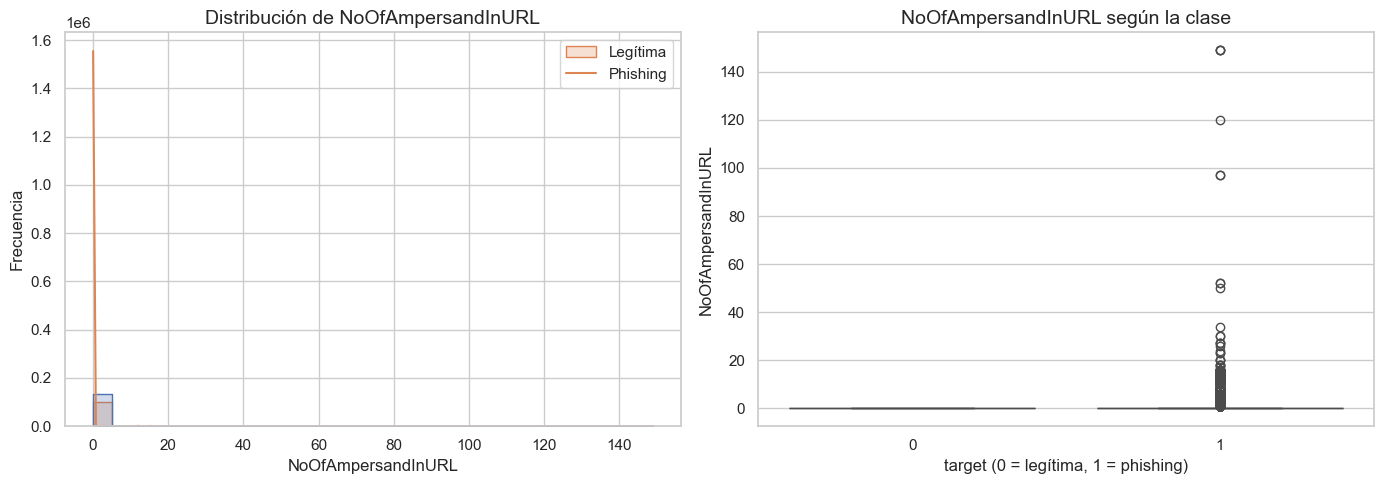


--- Análisis completo de: NoOfOtherSpecialCharsInURL ---


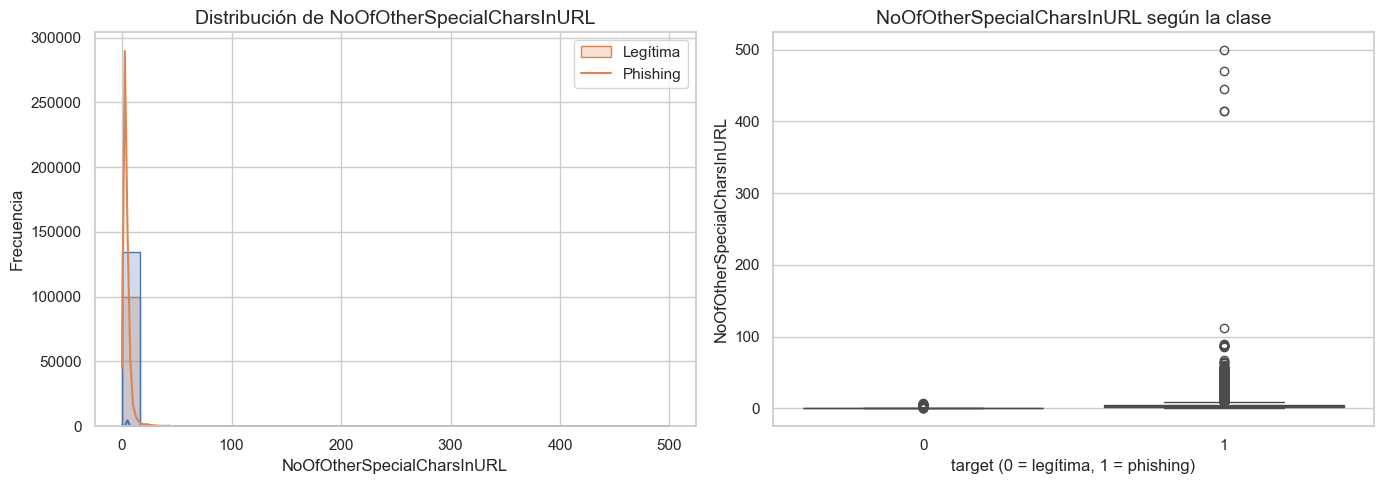


--- Análisis completo de: SpacialCharRatioInURL ---


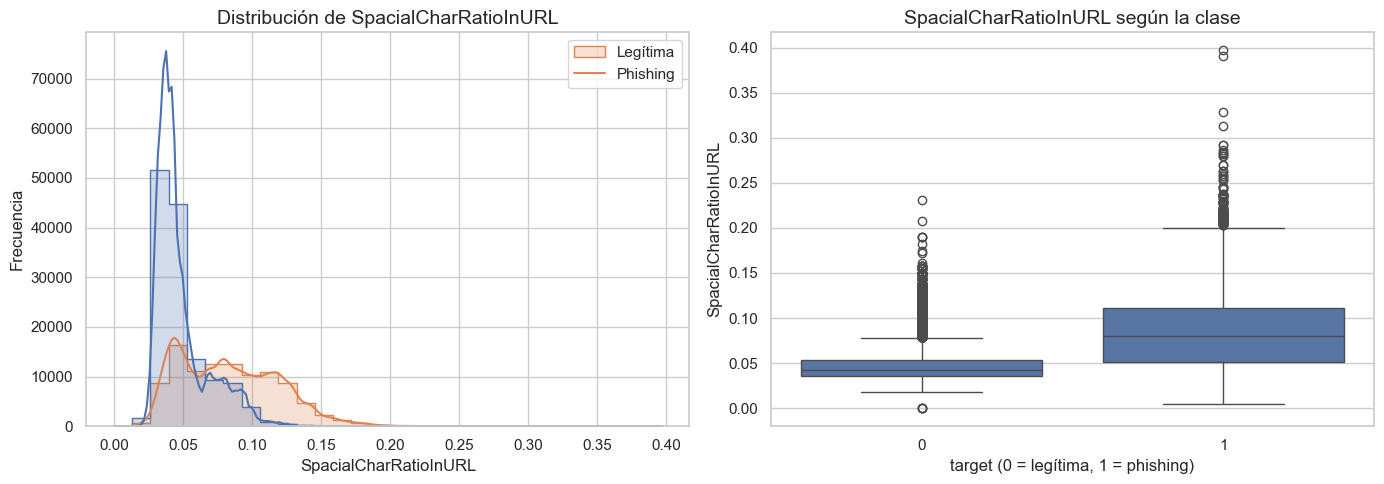


--- Análisis completo de: IsHTTPS ---


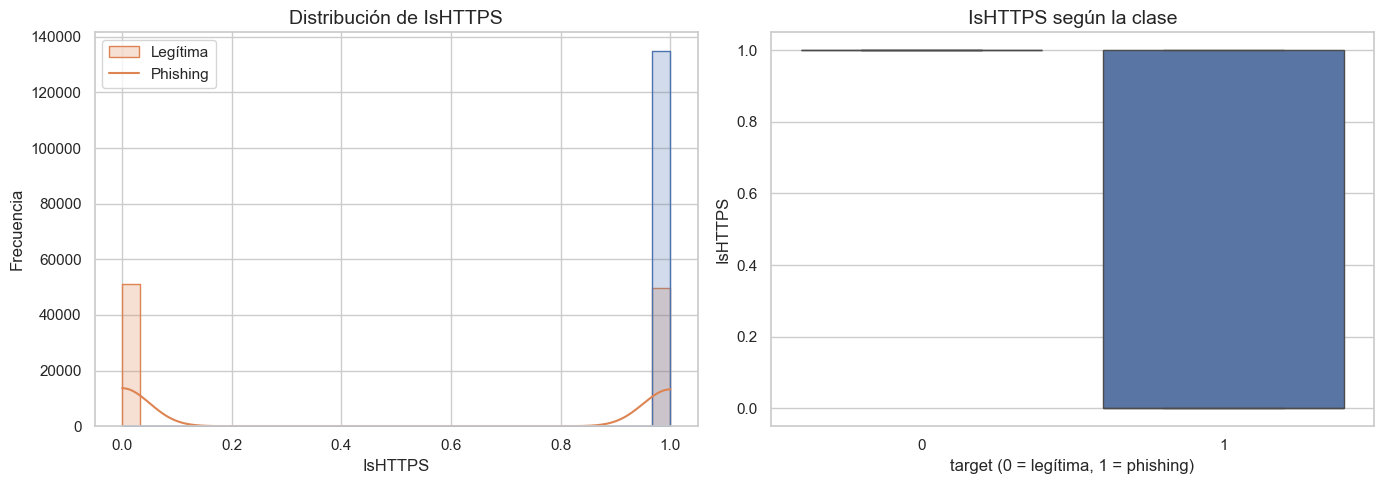


--- Análisis completo de: LineOfCode ---


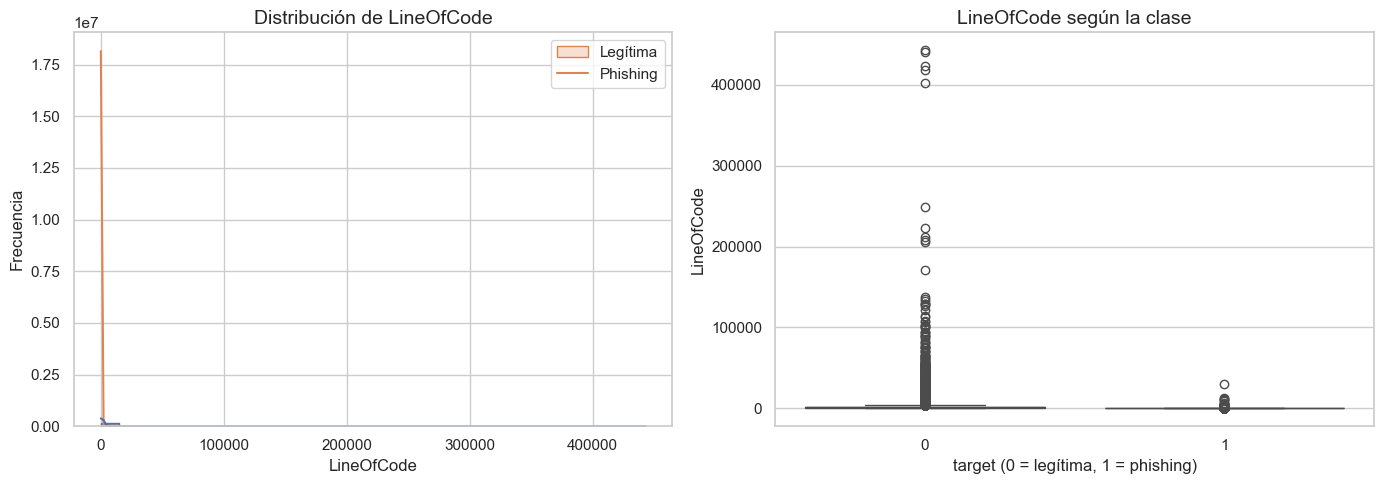


--- Análisis completo de: LargestLineLength ---


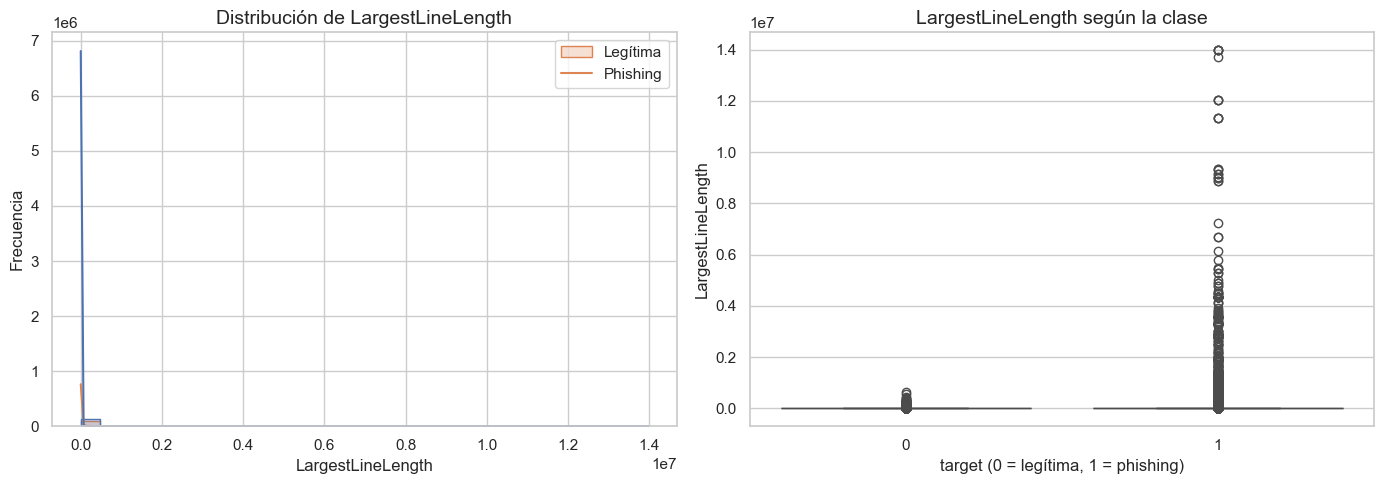


--- Análisis completo de: HasTitle ---


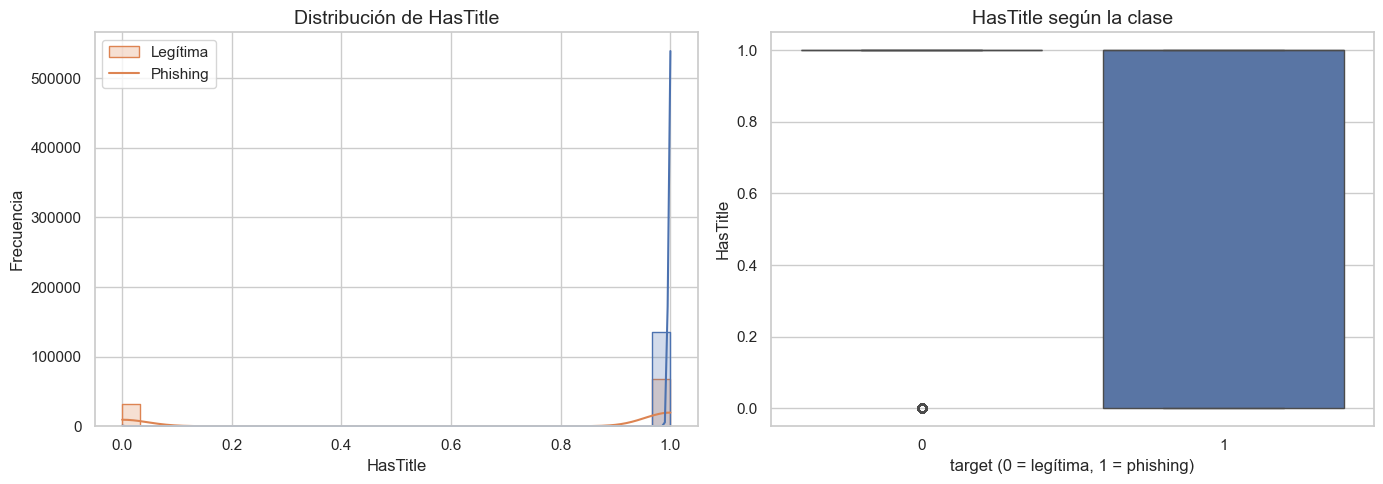


--- Análisis completo de: DomainTitleMatchScore ---


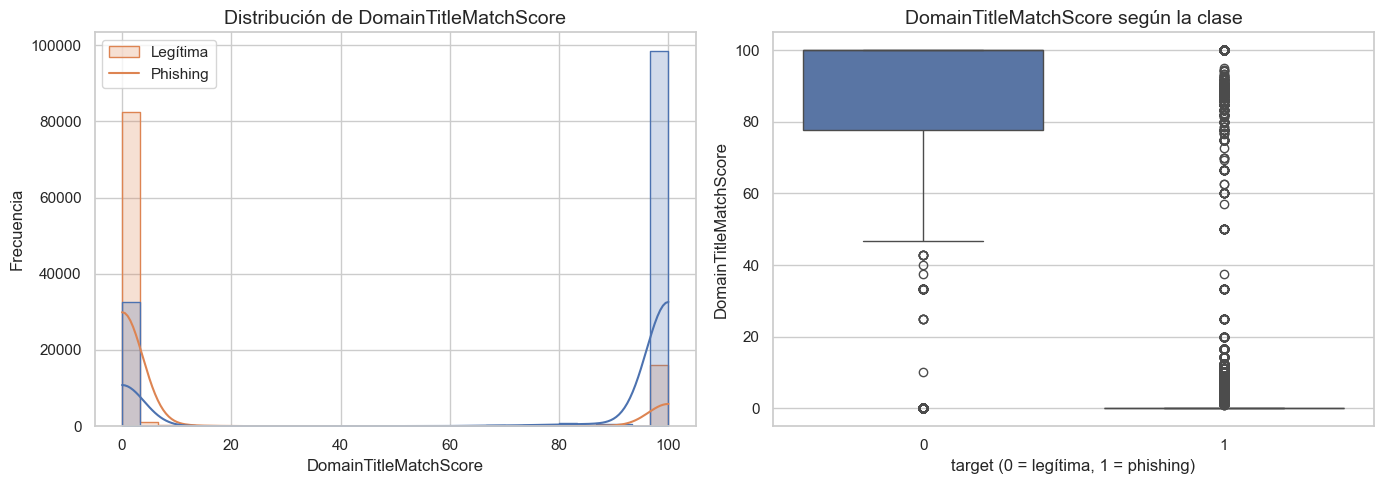


--- Análisis completo de: URLTitleMatchScore ---


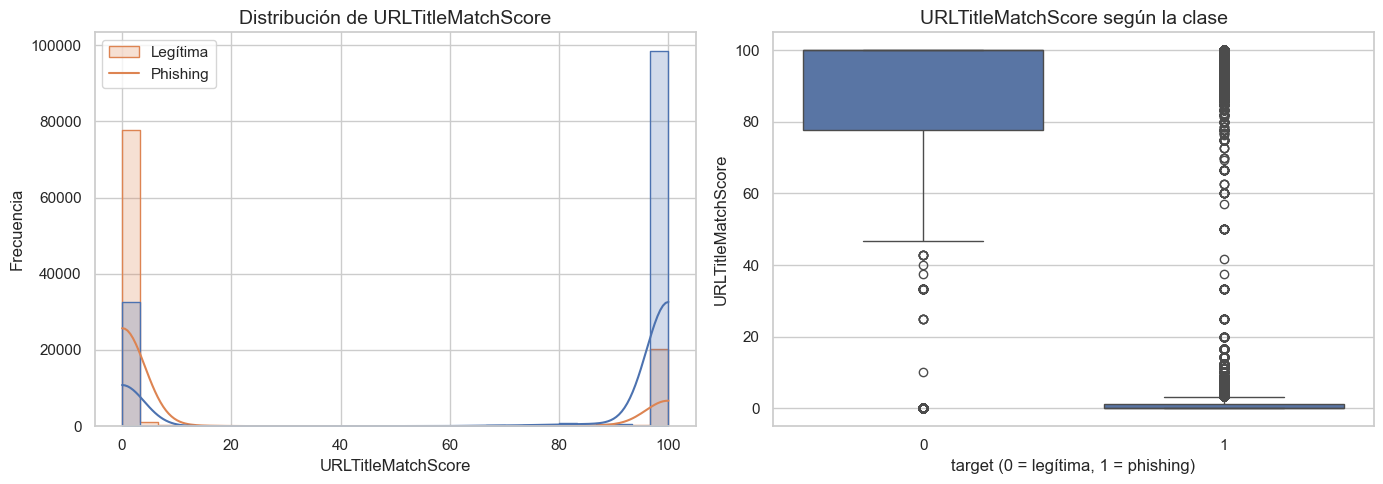


--- Análisis completo de: HasFavicon ---


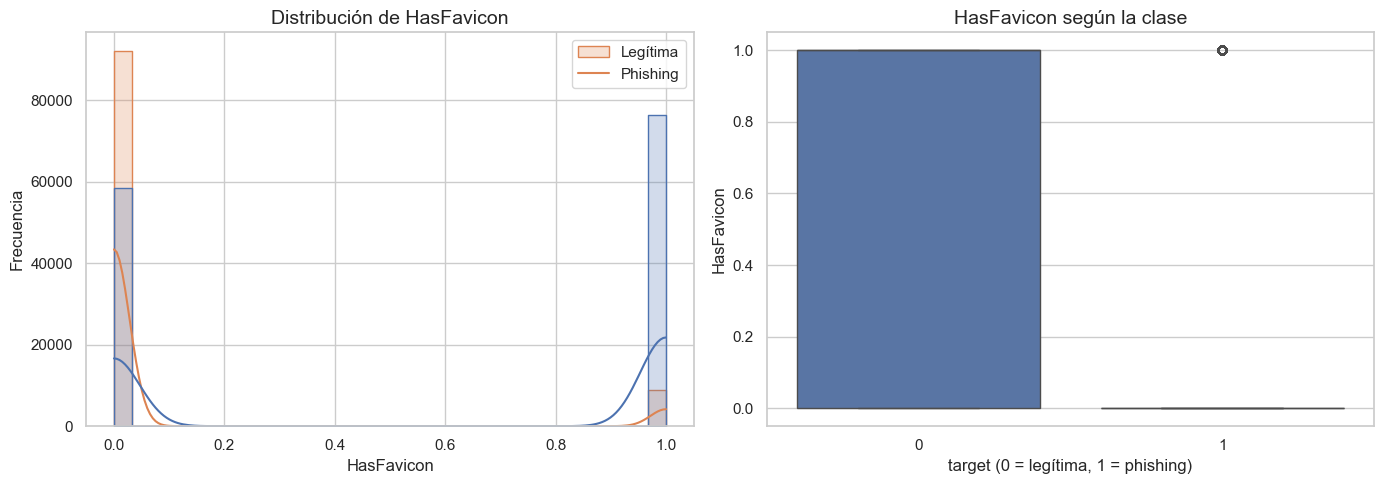


--- Análisis completo de: Robots ---


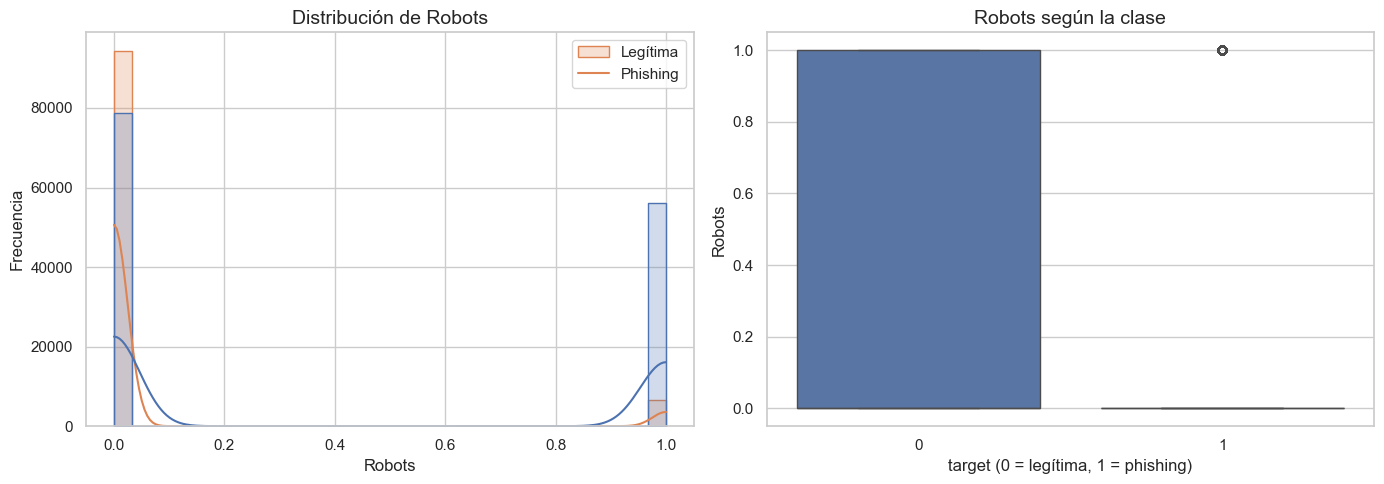


--- Análisis completo de: IsResponsive ---


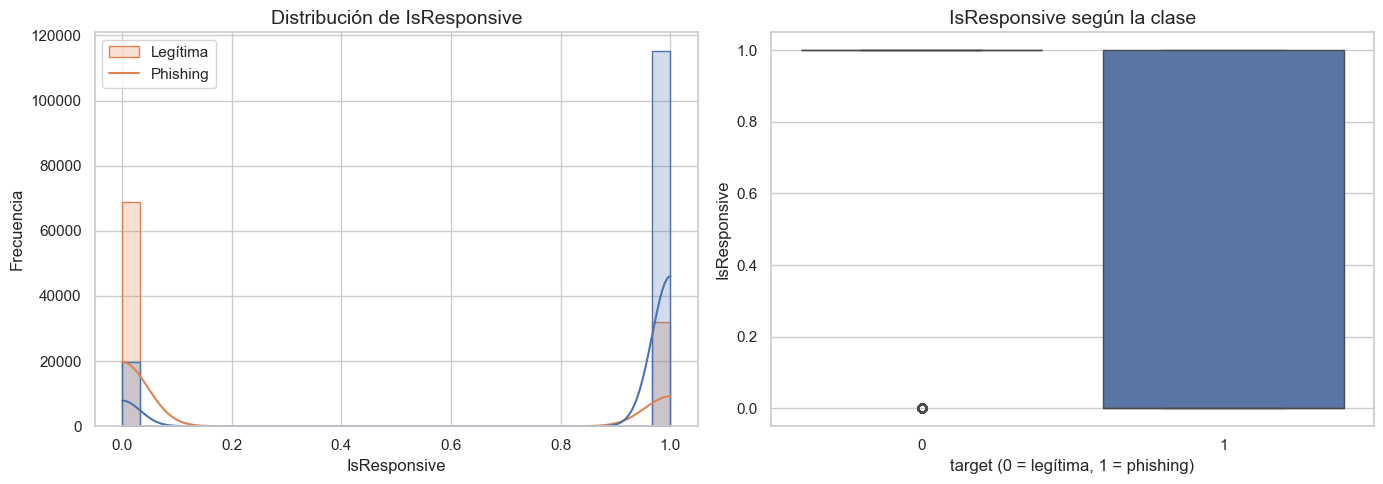


--- Análisis completo de: NoOfURLRedirect ---


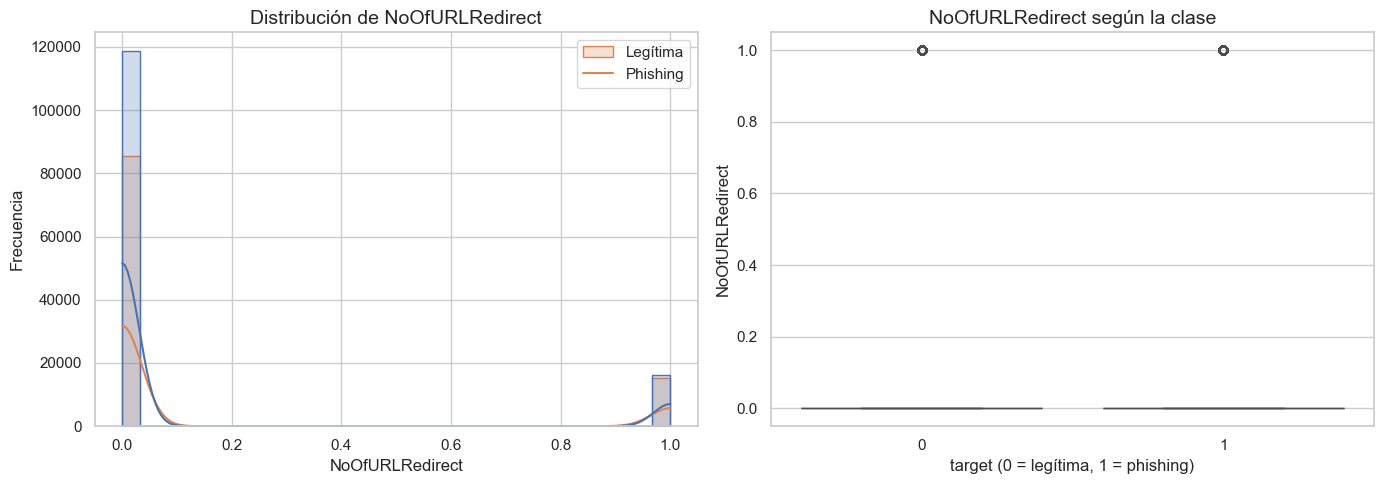


--- Análisis completo de: NoOfSelfRedirect ---


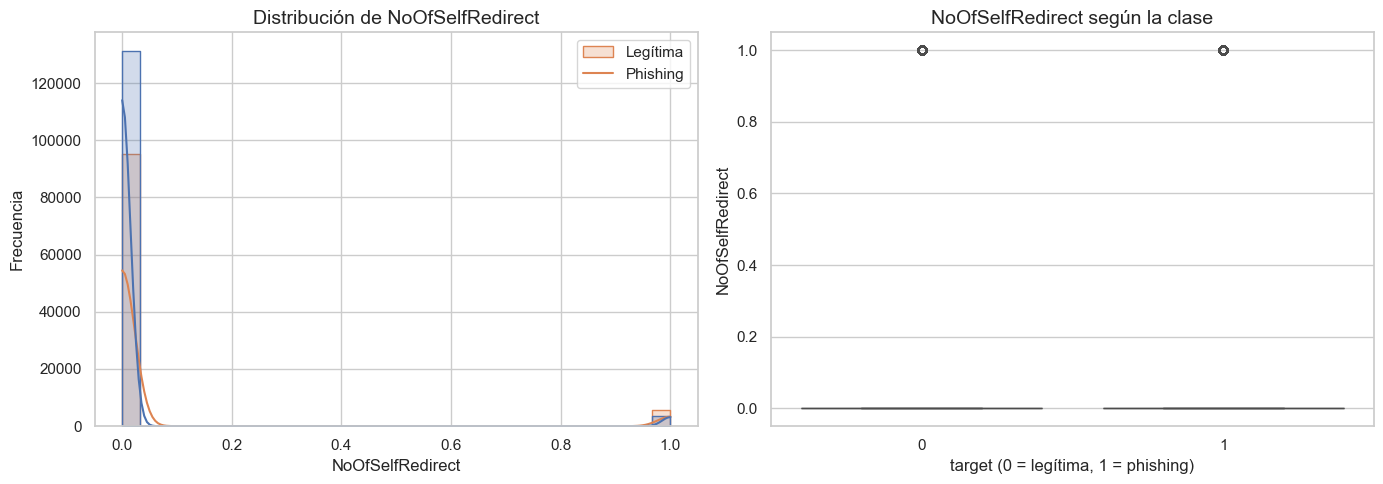


--- Análisis completo de: HasDescription ---


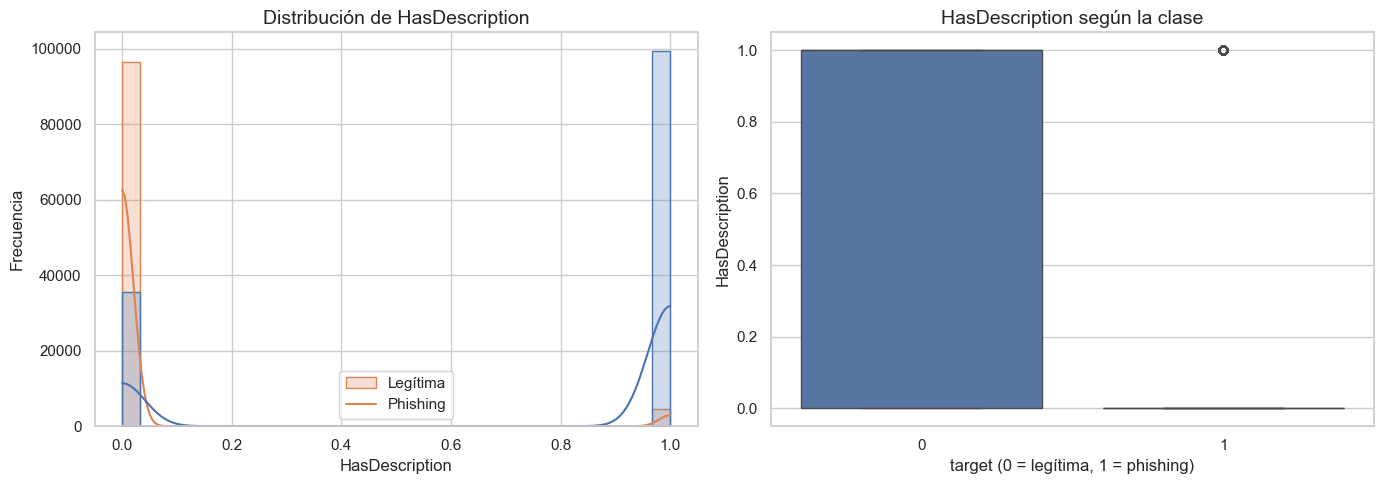


--- Análisis completo de: NoOfPopup ---


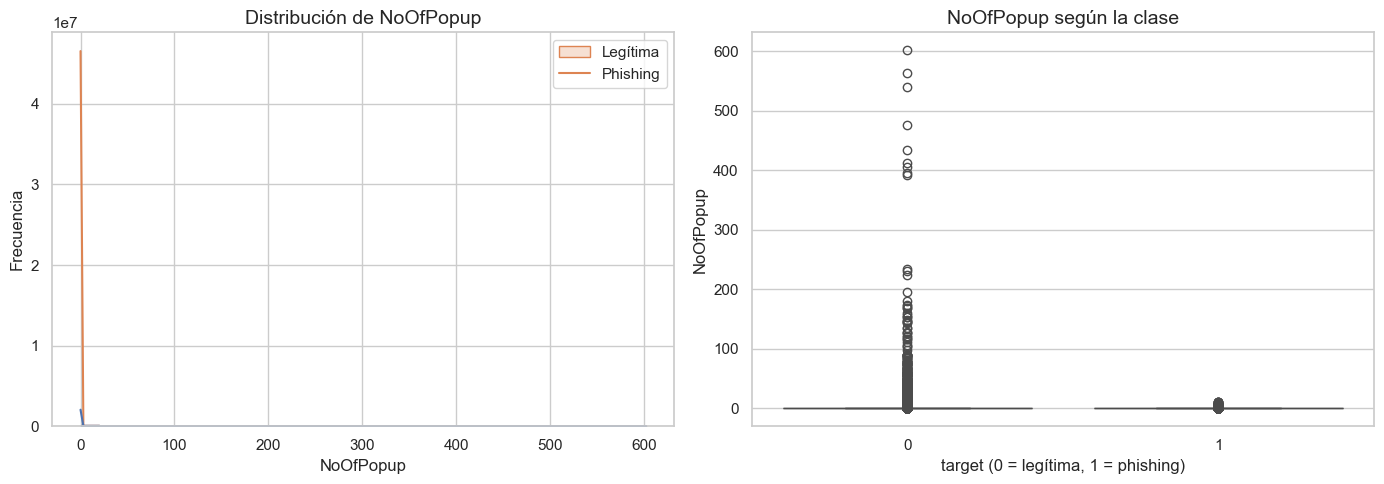


--- Análisis completo de: NoOfiFrame ---


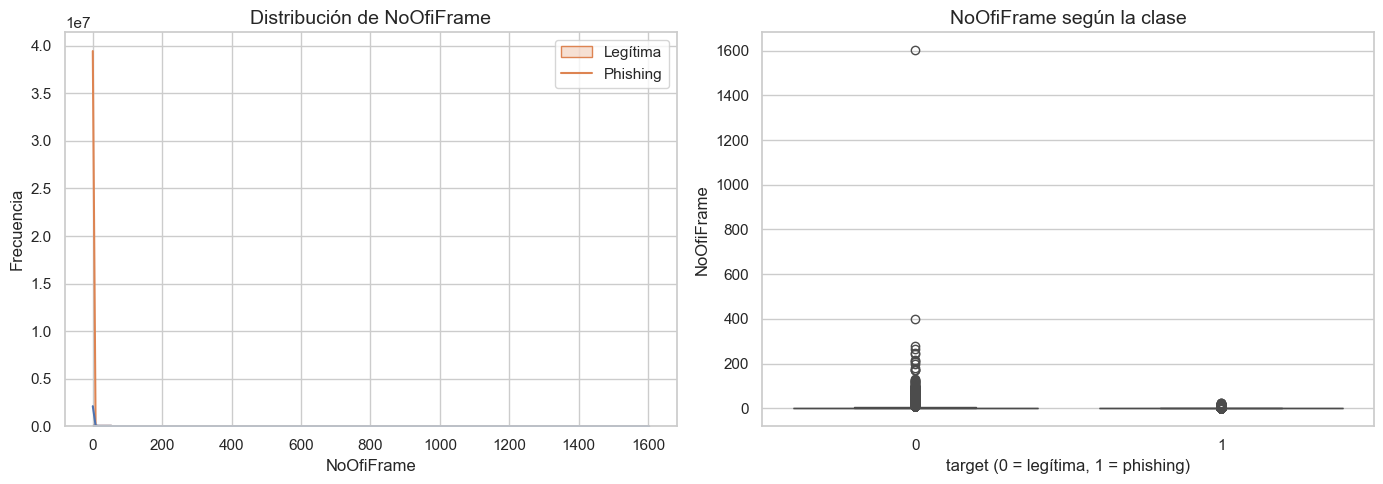


--- Análisis completo de: HasExternalFormSubmit ---


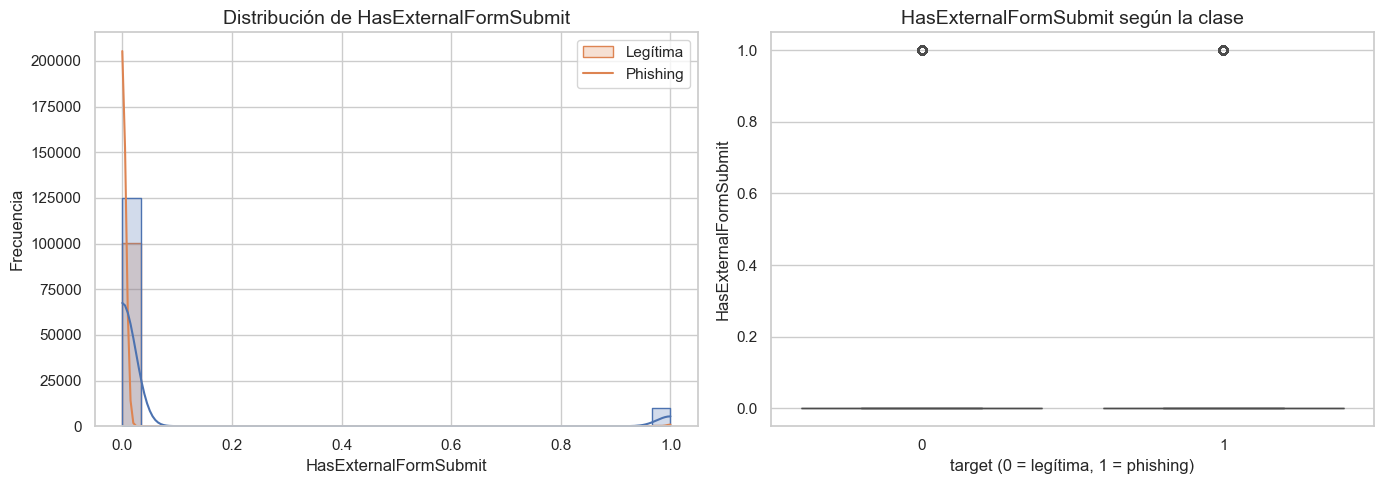


--- Análisis completo de: HasSocialNet ---


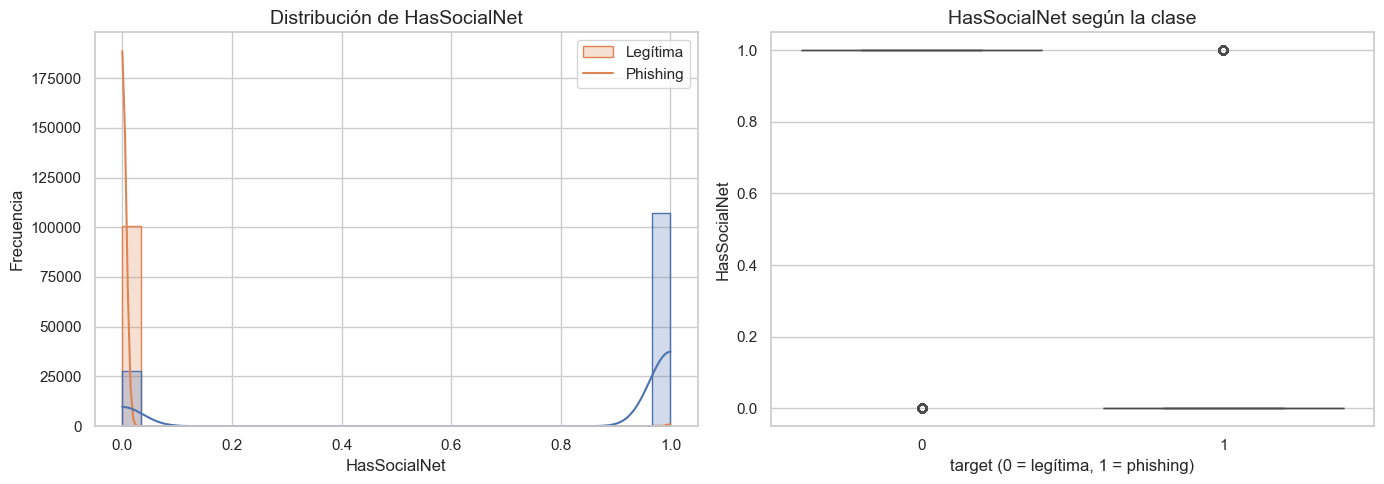


--- Análisis completo de: HasSubmitButton ---


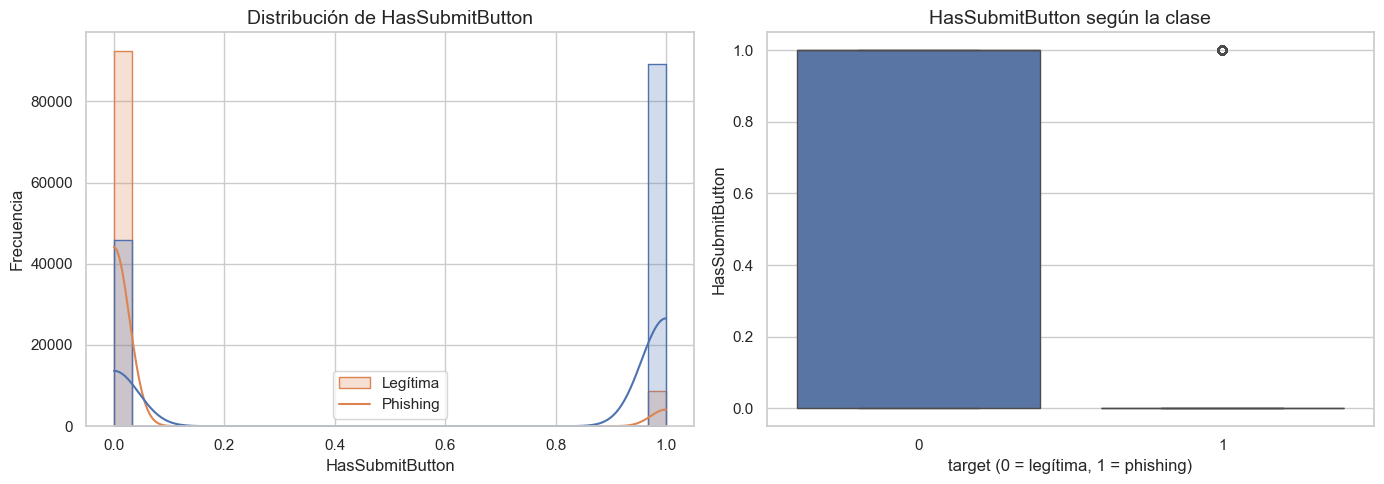


--- Análisis completo de: HasHiddenFields ---


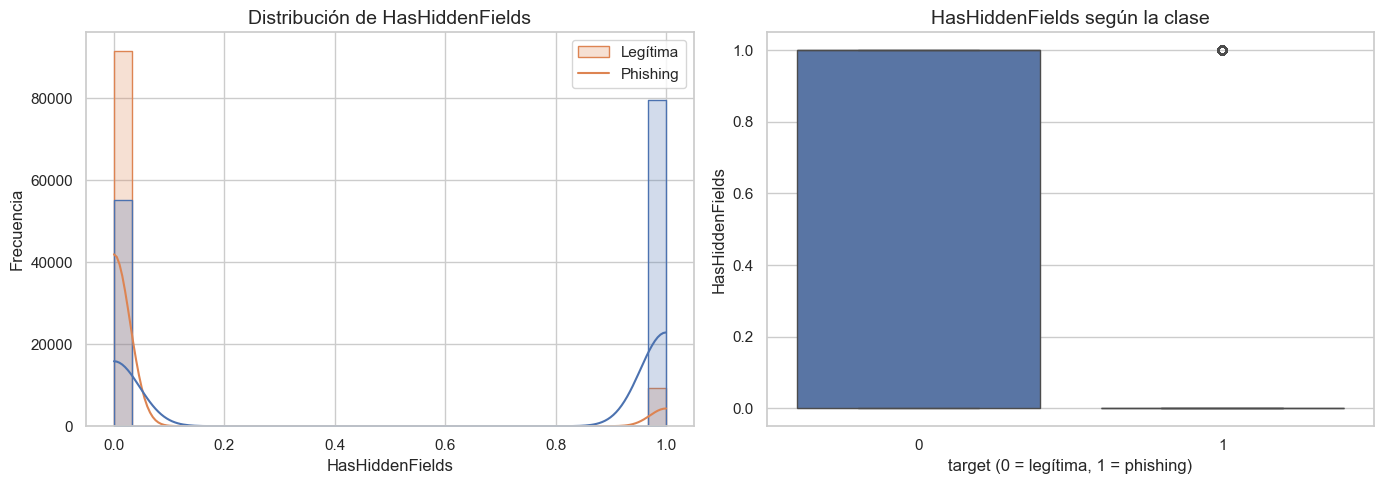


--- Análisis completo de: HasPasswordField ---


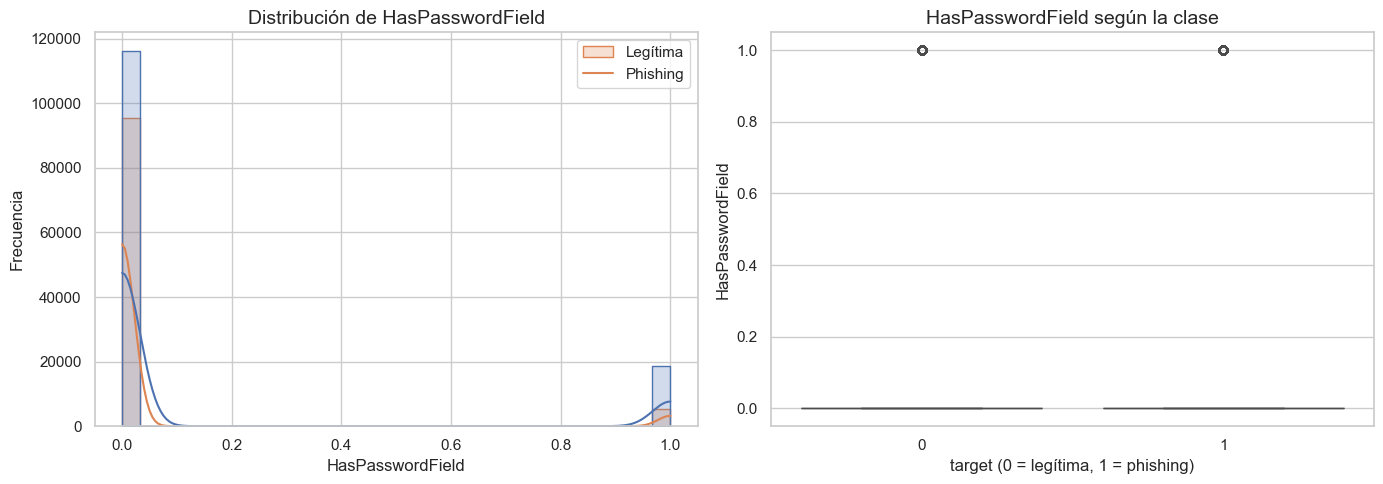


--- Análisis completo de: Bank ---


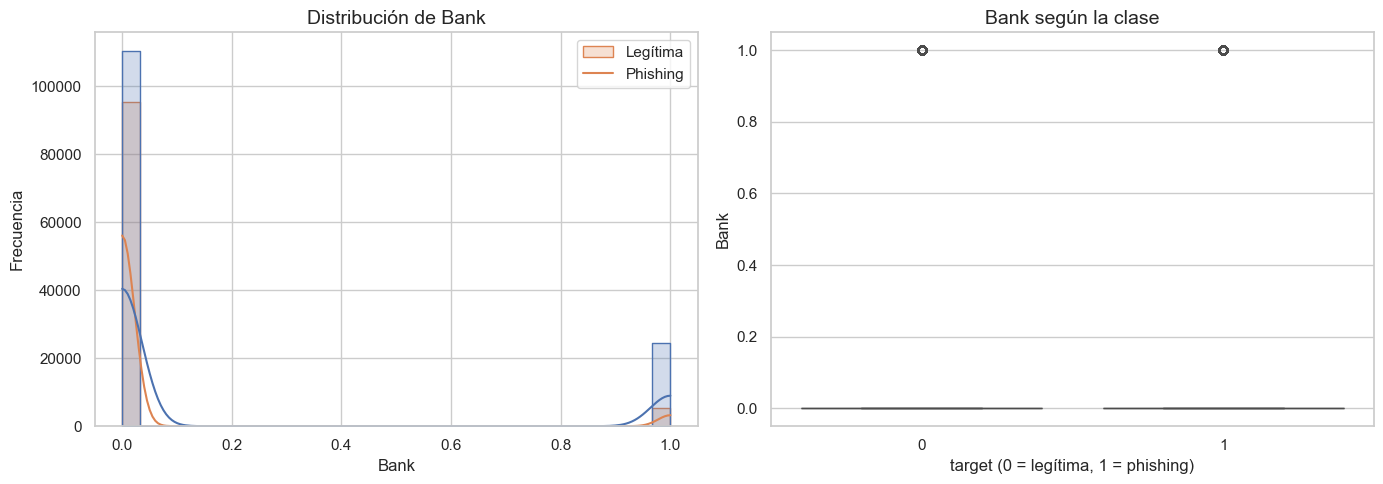


--- Análisis completo de: Pay ---


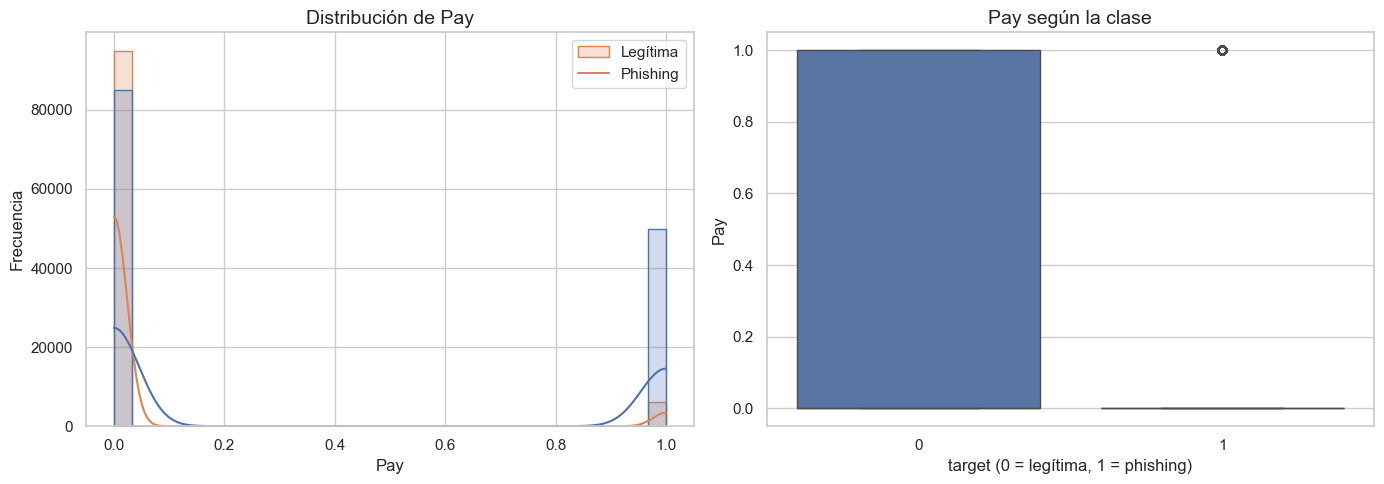


--- Análisis completo de: Crypto ---


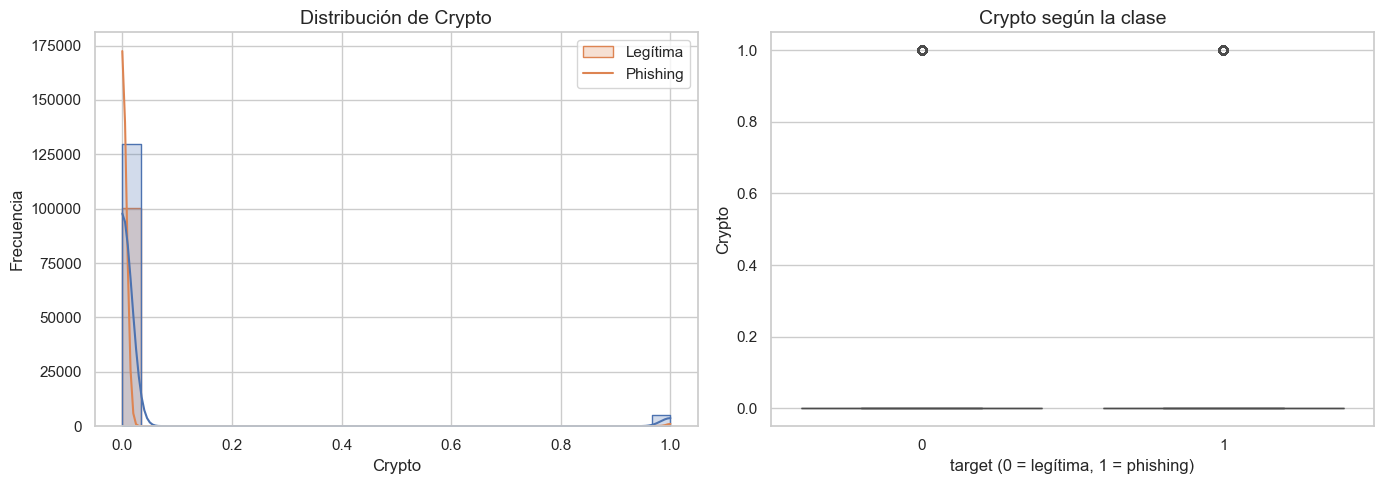


--- Análisis completo de: HasCopyrightInfo ---


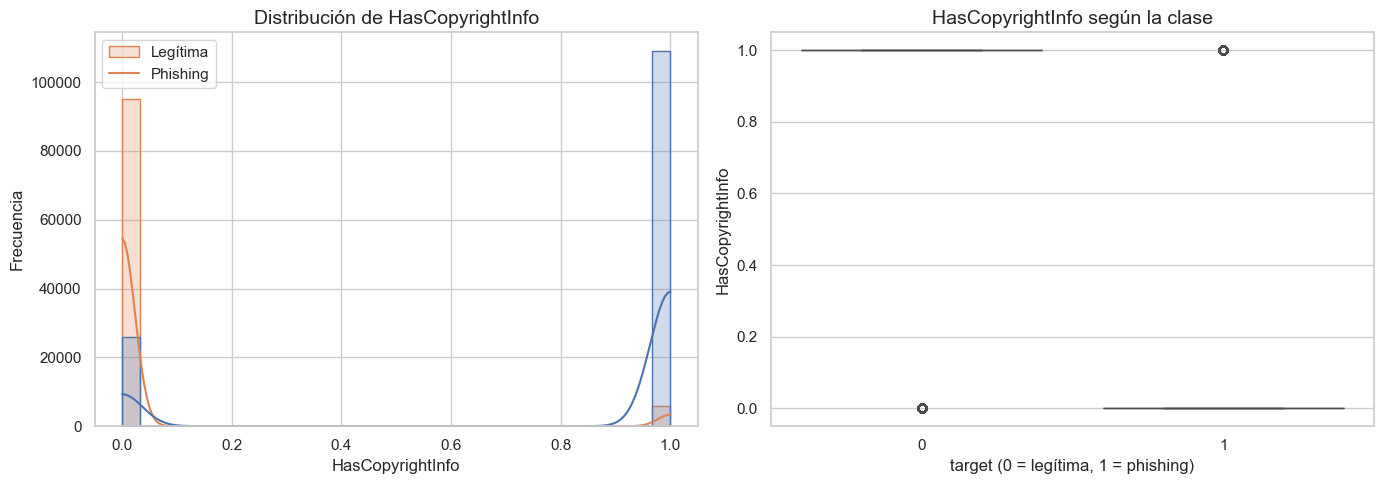


--- Análisis completo de: NoOfImage ---


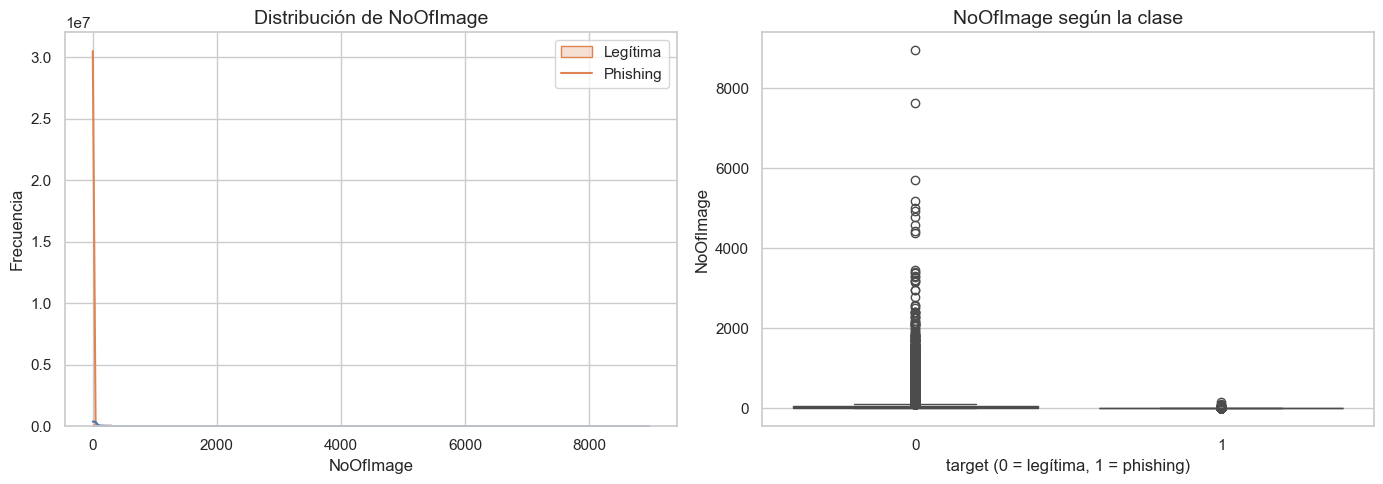


--- Análisis completo de: NoOfCSS ---


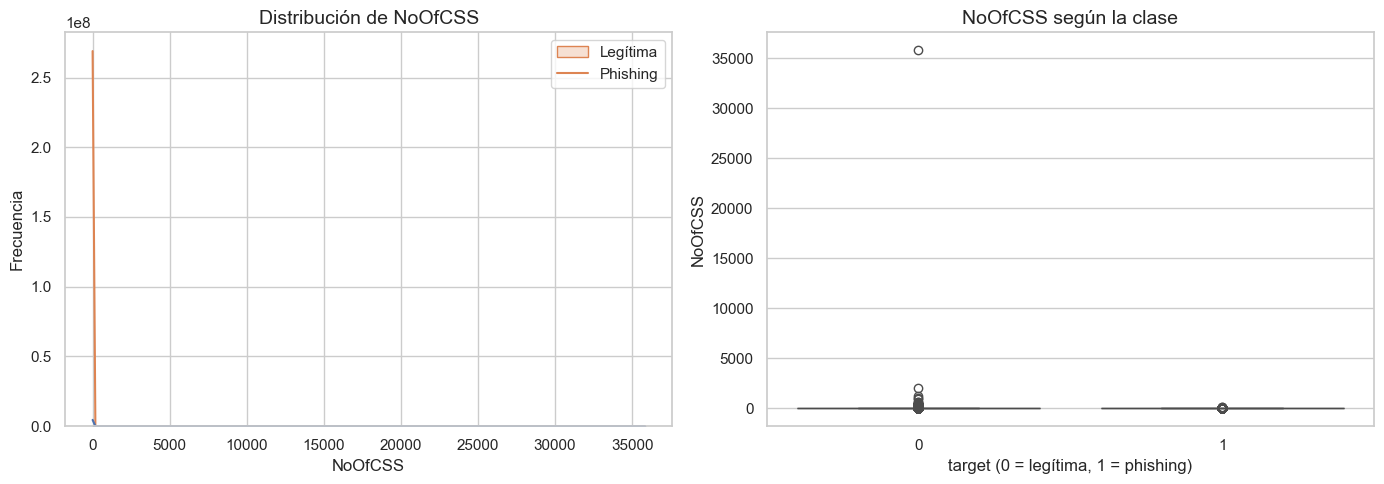


--- Análisis completo de: NoOfJS ---


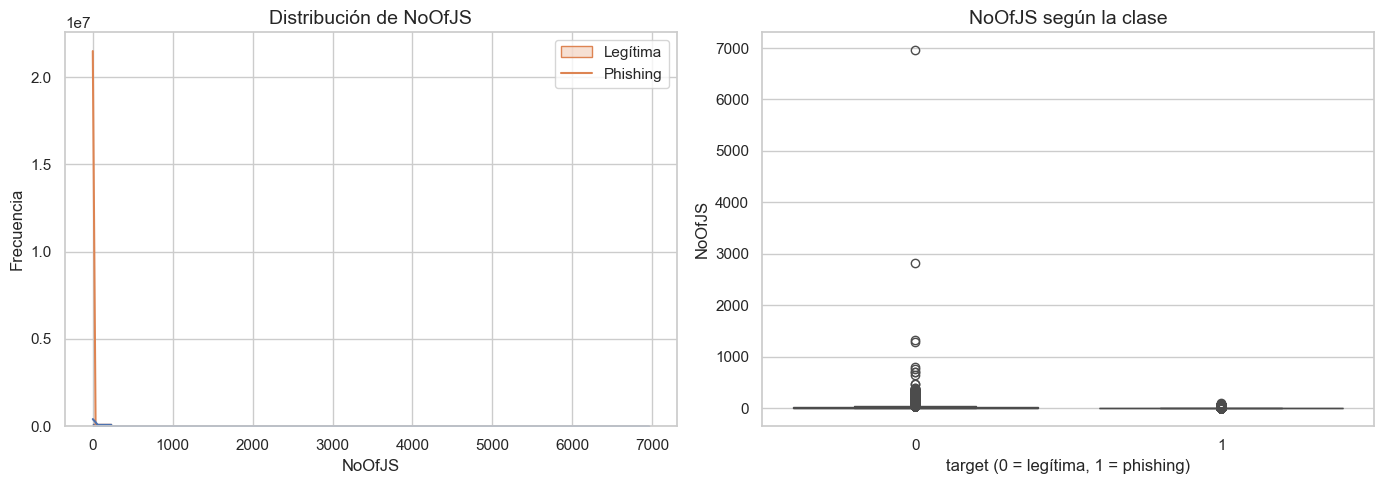


--- Análisis completo de: NoOfSelfRef ---


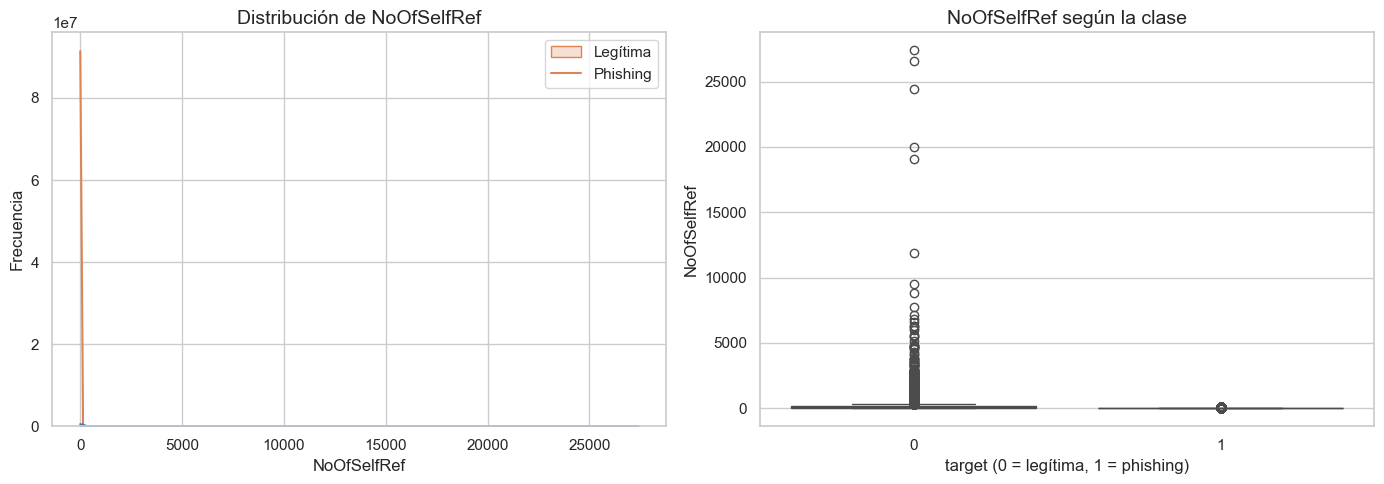


--- Análisis completo de: NoOfEmptyRef ---


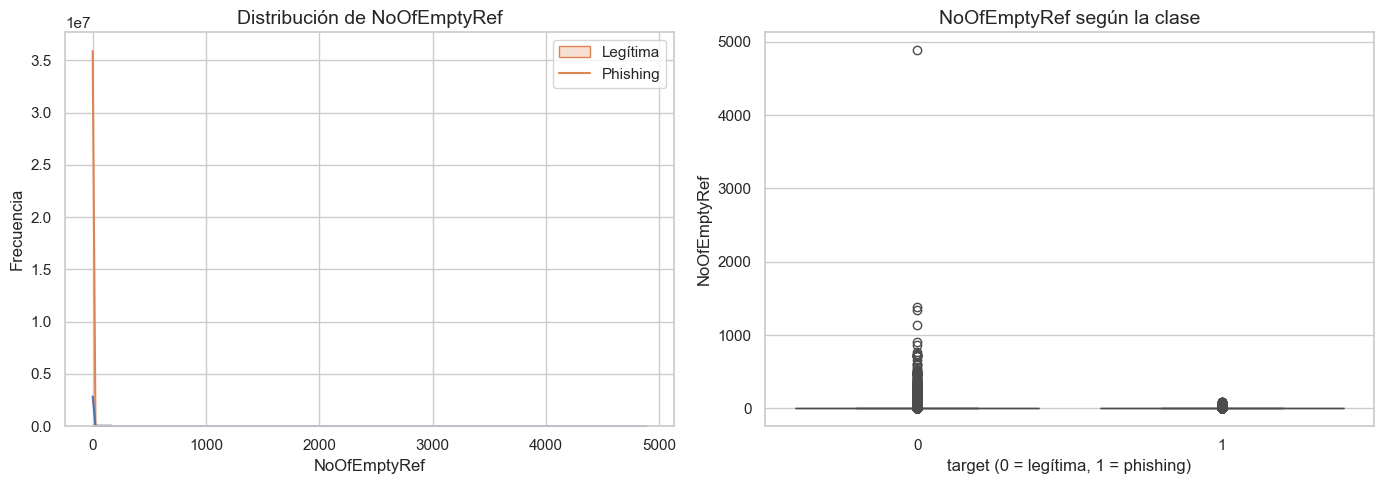


--- Análisis completo de: NoOfExternalRef ---


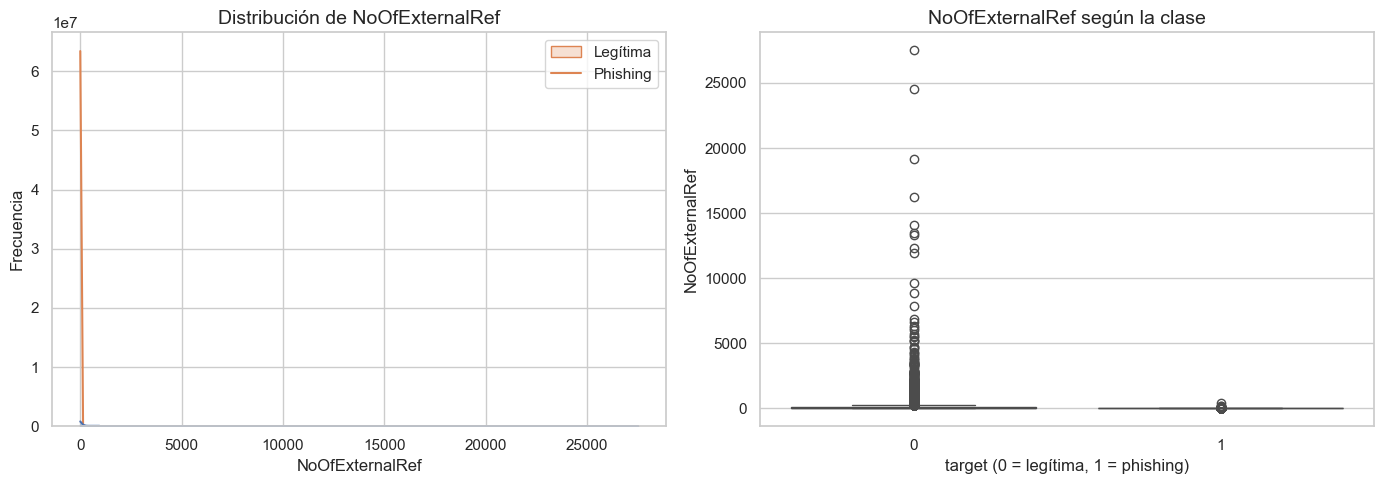

In [38]:
MOSTRAR_EDA_COMPLETO = True

if MOSTRAR_EDA_COMPLETO:
    for columna in columnas_caracteristicas:
        print(f"\n--- Análisis completo de: {columna} ---")
        graficar_variable_numerica(datos_modelo, columna)

### Lectura del EDA

En esta fase ya podemos extraer una idea importante:

- hay variables cuya distribución cambia de forma visible entre URLs legítimas y phishing;
- eso sugiere que el problema sí contiene **señal predictiva**;
- por tanto, un modelo supervisado bien entrenado debería ser capaz de capturar buena parte de esa diferencia.

# 3 - Preparación del modelado

## 3.1 - Definición de variables predictoras y objetivo

In [18]:
X = datos_modelo.drop(columns=["target"]).copy()
y = datos_modelo["target"].copy()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (235795, 50)
Shape de y: (235795,)


## 3.2 - División en entrenamiento y prueba

In [19]:
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_entrenamiento:", X_entrenamiento.shape)
print("X_prueba       :", X_prueba.shape)
print("y_entrenamiento:", y_entrenamiento.shape)
print("y_prueba       :", y_prueba.shape)

X_entrenamiento: (188636, 50)
X_prueba       : (47159, 50)
y_entrenamiento: (188636,)
y_prueba       : (47159,)


## 3.3 - Definición de pipelines de modelado

Vamos a comparar tres enfoques:

1. **Regresión logística** como baseline interpretable.
2. **Random Forest** como modelo de árbol robusto.
3. **XGBoost** como modelo de boosting potente para datos tabulares.

Esta comparación permite entender que no todos los modelos capturan el problema de la misma manera.

In [40]:
# ---------------------------------------------------------------------
# Pipeline 1 - Regresión logística
# ---------------------------------------------------------------------
pipeline_logistico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
        ("modelo", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# ---------------------------------------------------------------------
# Pipeline 2 - Random Forest
# ---------------------------------------------------------------------
pipeline_bosque = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("modelo", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# ---------------------------------------------------------------------
# Pipeline 3 - XGBoost
# ---------------------------------------------------------------------
pipeline_xgboost = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("modelo", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.85,
            colsample_bytree=0.7,
            reg_lambda=0.5,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

## 3.4 - Función auxiliar para entrenamiento y evaluación

In [41]:
def calcular_metricas_binarias(y_real, y_pred, y_prob, nombre_modelo):
    '''
    Devuelve una fila con las métricas principales de clasificación binaria.
    Se interpreta la clase positiva como:
    1 = phishing
    '''

    matriz = confusion_matrix(y_real, y_pred)
    TN, FP, FN, TP = matriz.ravel()

    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan

    return pd.DataFrame([{
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred),
        "recall_sensitivity": recall_score(y_real, y_pred),
        "specificity": specificity,
        "f1_score": f1_score(y_real, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_real, y_pred),
        "roc_auc": roc_auc_score(y_real, y_prob),
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    }])


def entrenar_y_evaluar_pipeline(nombre_modelo, pipeline, X_train, X_test, y_train, y_test):
    '''
    Entrena un pipeline, obtiene predicciones y devuelve:
    - pipeline ya entrenado,
    - dataframe con métricas,
    - predicciones binarias,
    - probabilidades.
    '''
    pipeline.fit(X_train, y_train)

    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["modelo"], "predict_proba"):
        prob_test = pipeline.predict_proba(X_test)[:, 1]
    else:
        # Si un modelo no expone predict_proba, intentamos una aproximación
        # basada en decision_function y una transformación logística.
        decision = pipeline.decision_function(X_test)
        prob_test = 1 / (1 + np.exp(-decision))

    metricas = calcular_metricas_binarias(y_test, pred_test, prob_test, nombre_modelo)
    metricas["accuracy_train"] = accuracy_score(y_train, pred_train)

    return pipeline, metricas, pred_test, prob_test

# 4 - Entrenamiento y comparación de modelos

## 4.1 - Entrenamiento del baseline y de los modelos finales

In [42]:
resultado_modelos = []

modelo_logistico, metricas_logistico, pred_logistico, prob_logistico = entrenar_y_evaluar_pipeline(
    "Regresión logística",
    pipeline_logistico,
    X_entrenamiento,
    X_prueba,
    y_entrenamiento,
    y_prueba
)

resultado_modelos.append(metricas_logistico)

modelo_bosque, metricas_bosque, pred_bosque, prob_bosque = entrenar_y_evaluar_pipeline(
    "Random Forest",
    pipeline_bosque,
    X_entrenamiento,
    X_prueba,
    y_entrenamiento,
    y_prueba
)

resultado_modelos.append(metricas_bosque)

modelo_xgboost, metricas_xgboost, pred_xgboost, prob_xgboost = entrenar_y_evaluar_pipeline(
    "XGBoost",
    pipeline_xgboost,
    X_entrenamiento,
    X_prueba,
    y_entrenamiento,
    y_prueba
)

resultado_modelos.append(metricas_xgboost)

## 4.2 - Comparación de resultados

In [43]:
tabla_resultados = pd.concat(resultado_modelos, axis=0).reset_index(drop=True)

columnas_tabla = [
    "modelo",
    "accuracy_train",
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "balanced_accuracy",
    "roc_auc"
]

display(
    tabla_resultados[columnas_tabla]
    .sort_values(by=["roc_auc", "balanced_accuracy"], ascending=False)
    .style.format({
        "accuracy_train": "{:.4f}",
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall_sensitivity": "{:.4f}",
        "specificity": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "roc_auc": "{:.4f}"
    })
)

,modelo,accuracy_train,accuracy,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,roc_auc
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
0,Regresión logística,0.9999,0.9999,1.0000,0.9998,1.0000,0.9999,0.9999,1.0000


### Interpretación de la tabla comparativa

En este punto conviene fijarse en varias métricas a la vez:

- **Accuracy**: porcentaje total de aciertos.
- **Precision**: de todas las URLs marcadas como phishing, cuántas lo eran realmente.
- **Recall Sensitivity**: de todas las URLs phishing reales, cuántas detecta el modelo.
- **Specificity**: capacidad para reconocer URLs legítimas.
- **Balanced Accuracy**: equilibrio entre sensibilidad y especificidad.
- **ROC AUC**: calidad global del ranking probabilístico del modelo.



## 4.3 - Selección del mejor modelo

In [44]:
tabla_resultados_ordenada = tabla_resultados.sort_values(
    by=["roc_auc", "balanced_accuracy", "recall_sensitivity"],
    ascending=False
).reset_index(drop=True)

nombre_mejor_modelo = tabla_resultados_ordenada.loc[0, "modelo"]
print("Mejor modelo según ROC AUC + Balanced Accuracy:", nombre_mejor_modelo)

if nombre_mejor_modelo == "Regresión logística":
    mejor_modelo = modelo_logistico
    y_pred_mejor = pred_logistico
    y_prob_mejor = prob_logistico
elif nombre_mejor_modelo == "Random Forest":
    mejor_modelo = modelo_bosque
    y_pred_mejor = pred_bosque
    y_prob_mejor = prob_bosque
else:
    mejor_modelo = modelo_xgboost
    y_pred_mejor = pred_xgboost
    y_prob_mejor = prob_xgboost

Mejor modelo según ROC AUC + Balanced Accuracy: Random Forest


## 4.4 - Búsqueda opcional de hiperparámetros para XGBoost

La siguiente celda está pensada como ampliación.  
No es obligatoria para el desarrollo del notebook, pero sí resulta útil para mostrar una práctica habitual en Machine Learning: la **optimización de hiperparámetros**.

Se podrá desactivar para reducir tiempo de ejecución.

In [46]:
ACTIVAR_BUSQUEDA_HIPERPARAMETROS = True

if ACTIVAR_BUSQUEDA_HIPERPARAMETROS:
    espacio_hiperparametros = {
        "modelo__n_estimators": [200, 300, 400],
        "modelo__max_depth": [4, 6, 8],
        "modelo__learning_rate": [0.03, 0.05, 0.08, 0.10],
        "modelo__subsample": [0.70, 0.85, 1.00],
        "modelo__colsample_bytree": [0.70, 0.85, 1.00],
        "modelo__reg_lambda": [0.5, 1.0, 2.0]
    }

    busqueda_xgb = RandomizedSearchCV(
        estimator=pipeline_xgboost,
        param_distributions=espacio_hiperparametros,
        n_iter=10,
        scoring="roc_auc",
        cv=3,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    busqueda_xgb.fit(X_entrenamiento, y_entrenamiento)

    print("Mejores hiperparámetros encontrados:")
    print(busqueda_xgb.best_params_)
    print("")
    print("Mejor ROC AUC en validación cruzada:", busqueda_xgb.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores hiperparámetros encontrados:
{'modelo__subsample': 0.85, 'modelo__reg_lambda': 0.5, 'modelo__n_estimators': 300, 'modelo__max_depth': 6, 'modelo__learning_rate': 0.1, 'modelo__colsample_bytree': 0.7}

Mejor ROC AUC en validación cruzada: 0.9999999979338998


# 5 - Evaluación detallada del mejor modelo

## 5.1 - Matriz de confusión

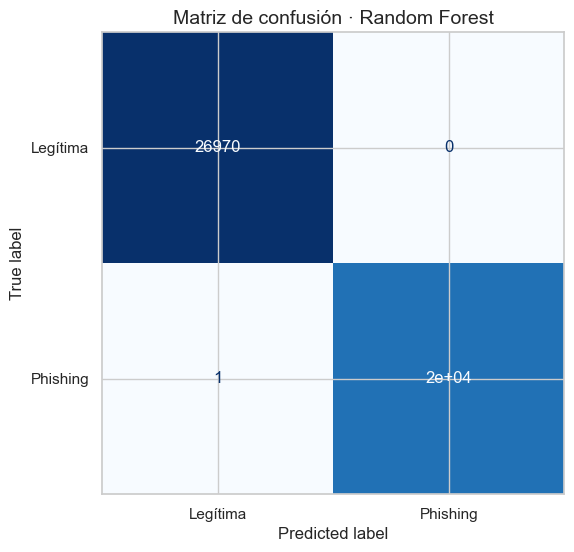

In [ ]:
matriz = confusion_matrix(y_prueba, y_pred_mejor)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Legítima", "Phishing"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión · {nombre_mejor_modelo}")
plt.show()

## 5.2 - Informe de clasificación

In [ ]:
print(f"Informe de clasificación del modelo: {nombre_mejor_modelo}")
print("")
print(classification_report(
    y_prueba,
    y_pred_mejor,
    target_names=["Legítima", "Phishing"]
))

Informe de clasificación del modelo: Random Forest

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     26970
    Phishing       1.00      1.00      1.00     20189

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



## 5.3 - Curvas ROC comparativas

<Figure size 1000x700 with 0 Axes>

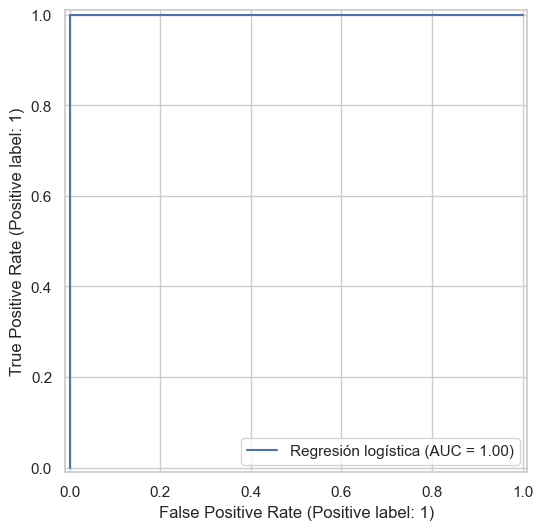

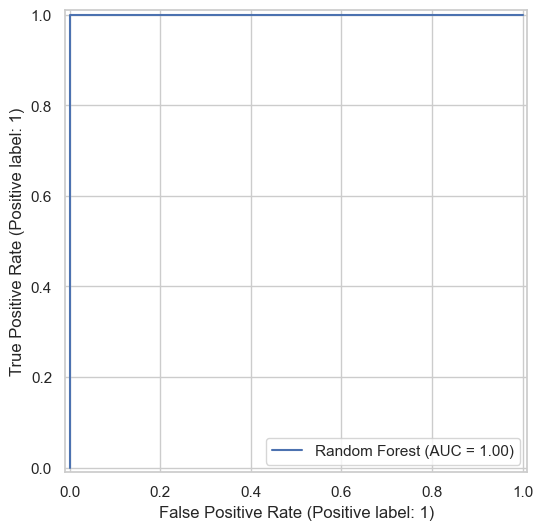

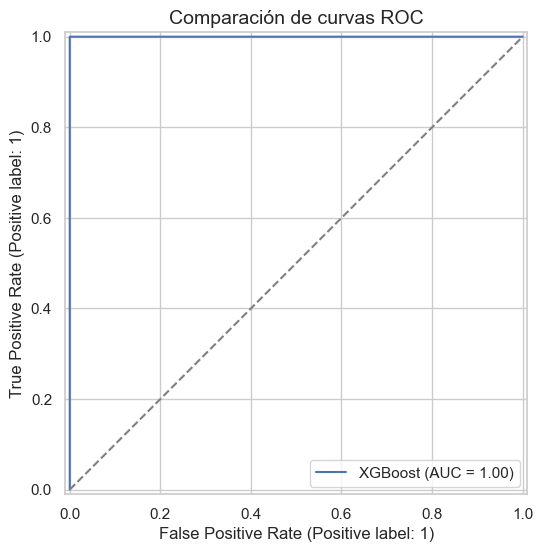

In [48]:
plt.figure(figsize=(10, 7))

RocCurveDisplay.from_predictions(y_prueba, prob_logistico, name="Regresión logística")
RocCurveDisplay.from_predictions(y_prueba, prob_bosque, name="Random Forest")
RocCurveDisplay.from_predictions(y_prueba, prob_xgboost, name="XGBoost")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Comparación de curvas ROC")
plt.show()

## 5.4 - Importancia de variables

Una de las grandes ventajas de este tipo de notebooks es que no solo entrenamos un modelo, sino que también intentamos entender **qué está aprendiendo**.

En esta sección extraeremos la importancia de las variables del mejor modelo.

In [49]:
def obtener_importancia_variables(modelo_entrenado, nombres_variables):
    '''
    Obtiene un dataframe con la importancia de variables para distintos
    tipos de modelo.
    '''
    estimador = modelo_entrenado.named_steps["modelo"]

    if hasattr(estimador, "feature_importances_"):
        importancia = estimador.feature_importances_
    elif hasattr(estimador, "coef_"):
        importancia = np.abs(estimador.coef_).ravel()
    else:
        raise ValueError("El modelo no expone ni feature_importances_ ni coef_.")

    tabla_importancia = pd.DataFrame({
        "variable": nombres_variables,
        "importancia": importancia
    }).sort_values(by="importancia", ascending=False)

    return tabla_importancia


tabla_importancia = obtener_importancia_variables(mejor_modelo, X.columns.tolist())
display(tabla_importancia.head(20))

,variable,importancia
3,URLSimilarityIndex,0.196516
49,NoOfExternalRef,0.151476
22,LineOfCode,0.119188
47,NoOfSelfRef,0.108904
44,NoOfImage,0.098028
46,NoOfJS,0.062973
36,HasSocialNet,0.045533
45,NoOfCSS,0.032249
32,HasDescription,0.026469
43,HasCopyrightInfo,0.026284


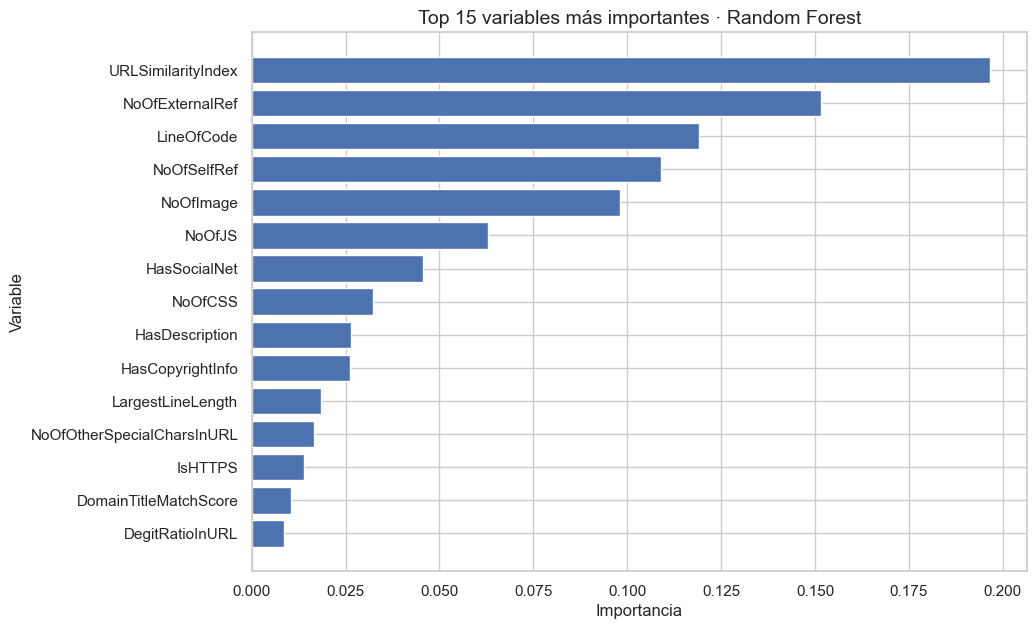

In [50]:
top_importancia = tabla_importancia.head(15).sort_values(by="importancia", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_importancia["variable"], top_importancia["importancia"])
plt.title(f"Top 15 variables más importantes · {nombre_mejor_modelo}")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## 5.5 - Análisis de errores del modelo

En clasificación binaria tenemos dos errores principales:

- **Falso positivo**: una URL legítima es marcada como phishing.
- **Falso negativo**: una URL phishing es marcada como legítima.

En ciberseguridad, los falsos negativos suelen ser especialmente delicados.

In [51]:
# ---------------------------------------------------------------------
# Construcción de un dataframe de análisis sobre el conjunto de prueba
# ---------------------------------------------------------------------
referencia_analisis = datos_brutos.loc[X_prueba.index].copy()

analisis_prueba = referencia_analisis.copy()
analisis_prueba["target_real"] = y_prueba.values
analisis_prueba["prediccion"] = y_pred_mejor
analisis_prueba["probabilidad_phishing"] = y_prob_mejor

analisis_prueba["tipo_resultado"] = np.select(
    [
        (analisis_prueba["target_real"] == 1) & (analisis_prueba["prediccion"] == 1),
        (analisis_prueba["target_real"] == 0) & (analisis_prueba["prediccion"] == 0),
        (analisis_prueba["target_real"] == 0) & (analisis_prueba["prediccion"] == 1),
        (analisis_prueba["target_real"] == 1) & (analisis_prueba["prediccion"] == 0),
    ],
    [
        "Verdadero Positivo",
        "Verdadero Negativo",
        "Falso Positivo",
        "Falso Negativo"
    ],
    default="Otro"
)

display(analisis_prueba.head())

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,target_original,target,target_real,prediccion,probabilidad_phishing,tipo_resultado
130287,https://www.vdlnews.com,22,www.vdlnews.com,15,0,com,100.000000,1.000000,0.522907,0.052530,3,1,0,0,0.0,9,0.409,0,0.0,0,0,0,1,0.045,1,3090,31225,1,vdlnews,100.0,100.0,0,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,71,8,24,221,10,19,1,0,0,0,0.00000,Verdadero Negativo
67439,http://www.shaparakpayer.cf,26,www.shaparakpayer.cf,20,0,cf,59.669358,1.000000,0.000186,0.055112,2,1,0,0,0.0,14,0.538,0,0.0,0,0,0,1,0.038,0,20,214,1,shaparakpayer,100.0,100.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1.00000,Verdadero Positivo
34963,https://www.destinyhandbags.com,30,www.destinyhandbags.com,23,0,com,100.000000,1.000000,0.522907,0.054191,3,1,0,0,0.0,17,0.567,0,0.0,0,0,0,1,0.033,1,181,760,1,destinyhandbags,100.0,100.0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,6,4,8,2,0,24,1,0,0,0,0.00000,Verdadero Negativo
30759,http://www.hkwindsacademy.synology.me,37,www.hkwindsacademy.synology.me,30,0,me,45.101907,0.652174,0.003638,0.052318,2,2,0,0,0.0,24,0.649,0,0.0,0,0,0,2,0.054,0,2,46,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1.00000,Verdadero Positivo
206263,https://www.caister.com,22,www.caister.com,15,0,com,100.000000,1.000000,0.522907,0.072794,3,1,0,0,0.0,9,0.409,0,0.0,0,0,0,1,0.045,1,215,380,1,caister,100.0,100.0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,4,1,1,76,0,76,1,0,0,0,0.00027,Verdadero Negativo


In [52]:
# ---------------------------------------------------------------------
# Resumen de tipos de resultado
# ---------------------------------------------------------------------
tabla_errores = (
    analisis_prueba["tipo_resultado"]
    .value_counts()
    .rename_axis("tipo_resultado")
    .reset_index(name="frecuencia")
)

tabla_errores["porcentaje"] = 100 * tabla_errores["frecuencia"] / tabla_errores["frecuencia"].sum()
display(tabla_errores)

,tipo_resultado,frecuencia,porcentaje
0,Verdadero Negativo,26970,57.189508
1,Verdadero Positivo,20188,42.808372
2,Falso Negativo,1,0.002120


In [53]:
# ---------------------------------------------------------------------
# Ejemplos de falsos negativos
# ---------------------------------------------------------------------
# Son URLs phishing que el modelo ha dejado pasar como si fueran legítimas.
columnas_mostrar = [col for col in ["URL", "Domain", "URLLength", "DomainLength", "URLSimilarityIndex", "TLDLegitimateProb"] if col in analisis_prueba.columns]

falsos_negativos = analisis_prueba[analisis_prueba["tipo_resultado"] == "Falso Negativo"].copy()
falsos_negativos = falsos_negativos.sort_values(by="probabilidad_phishing", ascending=True)

print("Ejemplos de falsos negativos:")
display(falsos_negativos[columnas_mostrar + ["probabilidad_phishing"]].head(10))

Ejemplos de falsos negativos:


,URL,Domain,URLLength,DomainLength,URLSimilarityIndex,TLDLegitimateProb,probabilidad_phishing
47436,http://www.electionleaks.com,www.electionleaks.com,27,21,100.0,0.522907,0.483234


In [54]:
# ---------------------------------------------------------------------
# Ejemplos de falsos positivos
# ---------------------------------------------------------------------
# Son URLs legítimas que el modelo ha marcado incorrectamente como phishing.
falsos_positivos = analisis_prueba[analisis_prueba["tipo_resultado"] == "Falso Positivo"].copy()
falsos_positivos = falsos_positivos.sort_values(by="probabilidad_phishing", ascending=False)

print("Ejemplos de falsos positivos:")
display(falsos_positivos[columnas_mostrar + ["probabilidad_phishing"]].head(10))

Ejemplos de falsos positivos:


,URL,Domain,URLLength,DomainLength,URLSimilarityIndex,TLDLegitimateProb,probabilidad_phishing


# 6 - Conclusión final

## 6.1 - Conclusiones técnicas

A partir de este notebook podemos extraer varias conclusiones:

- el dataset contiene suficiente información para distinguir, con bastante calidad, entre URLs legítimas y phishing;
- métricas como **recall**, **specificity**, **balanced accuracy** y **ROC AUC** son más informativas que mirar únicamente la accuracy.

## 6.2 - Conclusiones metodológicas

Desde el punto de vista del aprendizaje, este notebook ilustra un flujo de trabajo completo de Machine Learning:

1. comprensión del problema;
2. lectura y preparación del dataset;
3. análisis exploratorio;
4. diseño del conjunto de variables;
5. entrenamiento de varios modelos;
6. comparación de resultados;
7. análisis de importancia de variables;
8. estudio de errores.
